# Weather Similarity Research Pipeline


In [47]:
import os
import sys
import ast
import warnings
from dataclasses import dataclass
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.covariance import LedoitWolf
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 300)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

sys.path.append('/data1/elec_data/library')
from EnergyDataLoader.energydataloader import EnergyDataLoader
from EnergySQL.energysql import EnergySQL

ed = EnergyDataLoader('shaanxi')
esql = EnergySQL('shaanxi', 'Shaanxi_Weather_s3')

BASE_ORDERBOOK_DIR = '/data1/elec_data/sqldata/shaanxi/Shaanxi_OrderBook_s1'
BASE_FEATURES = ['win100_spd', 't2', 'rhu', 'd2', 'sf', 'sp', 'tp', 'ssrd', 'u100', 'v100', 'tcc']


In [5]:
def quick_data_check(df: pd.DataFrame, name: str):
    print(f'===== {name} =====')
    print('shape:', df.shape)
    if df.empty:
        print('empty dataframe')
        return
    print('index range:', df.index.min(), '->', df.index.max())
    print('duplicate index:', df.index.duplicated().sum())
    print('null ratio:')
    print(df.isna().mean().sort_values(ascending=False).head(15))
    print()


def sanitize_feature_list(df: pd.DataFrame, features: List[str]) -> List[str]:
    seen = set()
    cleaned = []
    for f in features:
        if f in df.columns and f not in seen:
            cleaned.append(f)
            seen.add(f)
    return cleaned


def debug_feature_list(df: pd.DataFrame, features: List[str], name: str):
    print(f'===== {name} =====')
    print('raw feature count:', len(features))
    uniq = list(dict.fromkeys(features))
    print('unique feature count:', len(uniq))
    missing = [f for f in uniq if f not in df.columns]
    print('missing count:', len(missing))
    if missing:
        print('missing sample:', missing[:20])
    dup = pd.Series(features).value_counts()
    dup = dup[dup > 1]
    print('duplicate count:', len(dup))
    if len(dup) > 0:
        print(dup.head(20))


In [6]:
def _safe_parse_book(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except Exception:
            return []
    return x if isinstance(x, (list, tuple)) else []


def _extract_level(x, first=True):
    x = _safe_parse_book(x)
    if len(x) == 0:
        return np.nan, np.nan
    try:
        level = x[0] if first else x[-1]
        return float(level[0]), float(level[1])
    except Exception:
        return np.nan, np.nan


def get_orderbook_data(start_time: str, end_time: str, base_dir: str = BASE_ORDERBOOK_DIR) -> pd.DataFrame:
    dfs = []
    for d in sorted(os.listdir(base_dir)):
        t2_dir = os.path.join(base_dir, d, 'T2')
        if not os.path.isdir(t2_dir):
            continue
        for root, _, files in os.walk(t2_dir):
            for fn in files:
                if fn.endswith('.parquet'):
                    fp = os.path.join(root, fn)
                    try:
                        dfs.append(pd.read_parquet(fp))
                    except Exception as e:
                        print(f'skip {fp}: {e}')
    if not dfs:
        return pd.DataFrame()

    trade_his = pd.concat(dfs, ignore_index=False, sort=False).sort_index()
    trade_his[['best_bid_price', 'best_bid_amt']] = trade_his['bids'].apply(lambda x: _extract_level(x, True)).tolist()
    trade_his[['best_ask_price', 'best_ask_amt']] = trade_his['asks'].apply(lambda x: _extract_level(x, False)).tolist()
    trade_his['mid_price'] = (trade_his['best_bid_price'] + trade_his['best_ask_price']) / 2.0
    trade_his['spread_book'] = trade_his['best_ask_price'] - trade_his['best_bid_price']
    return trade_his.loc[start_time:end_time].copy()


def get_rt_data(start_time: str, end_time: str) -> pd.DataFrame:
    return ed.pull(['da', 'rt'], start=start_time, end=end_time).rename_axis('time').sort_index()


def get_weather_data(features: List[str], start_date: str, end_date: str, NN: int = 1) -> pd.DataFrame:
    df = esql.select(features, start=start_date, end=end_date, NN=NN)
    return df.groupby('datetime').mean().sort_index()


def get_weather_snapshot_block(features: List[str], start_date: str, end_date: str, NN: int) -> pd.DataFrame:
    df = esql.select(features, start=start_date, end=end_date, NN=NN)
    return df.groupby('datetime').mean().sort_index()


In [51]:
def prepare_base_panel(start_date: str, end_date: str, weather_features: List[str]) -> pd.DataFrame:
    trade_his = get_orderbook_data(start_date, end_date)
    rt_real = get_rt_data(start_date, end_date)
    if trade_his.empty or rt_real.empty:
        return pd.DataFrame()

    common_idx = trade_his.index.intersection(rt_real.index)
    aligned = (
        trade_his.loc[common_idx, ['mid_price', 'best_bid_price', 'best_ask_price', 'spread_book']]
        .join(rt_real.loc[common_idx, ['rt']], how='inner')
        .sort_index()
    )
    aligned['prc_diff'] = aligned['mid_price'] - aligned['rt']
    aligned['prc_diff_sign'] = np.sign(aligned['prc_diff']).astype(float)
    aligned['hour'] = aligned.index.hour
    aligned['month'] = aligned.index.month
    aligned['dayofweek'] = aligned.index.dayofweek

    w_hist = get_weather_data(weather_features, pd.to_datetime(start_date).strftime('%Y%m%d'), pd.to_datetime(end_date).strftime('%Y%m%d'), NN=1)
    return aligned.join(w_hist, how='inner').sort_index()


def add_weather_trend_features(df: pd.DataFrame, weather_features: List[str], lags=(1, 4)) -> pd.DataFrame:
    out = df.copy()
    for col in weather_features:
        for lag in lags:
            out[f'{col}_diff_lag{lag}'] = out[col] - out[col].shift(lag)
        out[f'{col}_rollmean_3'] = out[col].rolling(3).mean()
        out[f'{col}_rollstd_3'] = out[col].rolling(3).std()
        out[f'{col}_slope_3'] = (out[col] - out[col].shift(3)) / 3.0
        out[f'{col}_rollmean_6'] = out[col].rolling(6).mean()
        out[f'{col}_rollstd_6'] = out[col].rolling(6).std()
        out[f'{col}_slope_6'] = (out[col] - out[col].shift(6)) / 6.0
    return out


def add_market_context_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['prc_diff_lag1'] = out['prc_diff'].shift(1)
    out['prc_diff_lag2'] = out['prc_diff'].shift(2)
    out['prc_diff_rollmean_3'] = out['prc_diff'].rolling(3).mean()
    out['prc_diff_rollstd_3'] = out['prc_diff'].rolling(3).std()
    out['mid_price_diff1'] = out['mid_price'] - out['mid_price'].shift(1)
    out['spread_book_rollmean_3'] = out['spread_book'].rolling(3).mean()
    out['spread_book_rollstd_3'] = out['spread_book'].rolling(3).std()
    return out


def add_calendar_regime_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['is_weekend'] = (out['dayofweek'] >= 5).astype(int)
    out['is_night'] = out['hour'].isin([0, 1, 2, 3, 4, 5]).astype(int)
    out['is_peak_hour'] = out['hour'].isin([8, 9, 10, 11, 17, 18, 19, 20]).astype(int)
    return out


def build_feature_panel(start_date: str, end_date: str, weather_features: List[str]) -> pd.DataFrame:
    df = prepare_base_panel(start_date, end_date, weather_features)
    if df.empty:
        return df
    df = add_weather_trend_features(df, weather_features, lags=(1, 4))
    df = add_market_context_features(df)
    df = add_calendar_regime_features(df)
    return df.sort_index()


panel0 = prepare_base_panel('20260101', '20260425', BASE_FEATURES)
quick_data_check(panel0, 'panel0')
panel0.head()


panel1 = build_feature_panel('20260101', '20260425', BASE_FEATURES)
quick_data_check(panel1, 'panel1')
panel1.head()


===== panel0 =====
shape: (1440, 21)
index range: 2026-01-24 00:00:00 -> 2026-04-25 23:00:00
duplicate index: 0
null ratio:
mid_price         0.0
rhu               0.0
v100              0.0
u100              0.0
tp                0.0
tcc               0.0
t2                0.0
ssrd              0.0
sp                0.0
sf                0.0
d2                0.0
best_bid_price    0.0
dayofweek         0.0
month             0.0
hour              0.0
dtype: float64

===== panel1 =====
shape: (1440, 119)
index range: 2026-01-24 00:00:00 -> 2026-04-25 23:00:00
duplicate index: 0
null ratio:
tp_slope_6            0.004167
sf_slope_6            0.004167
win100_spd_slope_6    0.004167
u100_slope_6          0.004167
sp_slope_6            0.004167
d2_slope_6            0.004167
v100_slope_6          0.004167
tcc_slope_6           0.004167
t2_slope_6            0.004167
rhu_slope_6           0.004167
ssrd_slope_6          0.004167
rhu_rollmean_6        0.003472
tp_rollstd_6          0.003472
t2

,mid_price,best_bid_price,best_ask_price,spread_book,rt,prc_diff,prc_diff_sign,hour,month,dayofweek,d2,rhu,sf,sp,ssrd,t2,tcc,tp,u100,v100,win100_spd,win100_spd_diff_lag1,win100_spd_diff_lag4,win100_spd_rollmean_3,win100_spd_rollstd_3,win100_spd_slope_3,win100_spd_rollmean_6,win100_spd_rollstd_6,win100_spd_slope_6,t2_diff_lag1,t2_diff_lag4,t2_rollmean_3,t2_rollstd_3,t2_slope_3,t2_rollmean_6,t2_rollstd_6,t2_slope_6,rhu_diff_lag1,rhu_diff_lag4,rhu_rollmean_3,rhu_rollstd_3,rhu_slope_3,rhu_rollmean_6,rhu_rollstd_6,rhu_slope_6,d2_diff_lag1,d2_diff_lag4,d2_rollmean_3,d2_rollstd_3,d2_slope_3,d2_rollmean_6,d2_rollstd_6,d2_slope_6,sf_diff_lag1,sf_diff_lag4,sf_rollmean_3,sf_rollstd_3,sf_slope_3,sf_rollmean_6,sf_rollstd_6,sf_slope_6,sp_diff_lag1,sp_diff_lag4,sp_rollmean_3,sp_rollstd_3,sp_slope_3,sp_rollmean_6,sp_rollstd_6,sp_slope_6,tp_diff_lag1,tp_diff_lag4,tp_rollmean_3,tp_rollstd_3,tp_slope_3,tp_rollmean_6,tp_rollstd_6,tp_slope_6,ssrd_diff_lag1,ssrd_diff_lag4,ssrd_rollmean_3,ssrd_rollstd_3,ssrd_slope_3,ssrd_rollmean_6,ssrd_rollstd_6,ssrd_slope_6,u100_diff_lag1,u100_diff_lag4,u100_rollmean_3,u100_rollstd_3,u100_slope_3,u100_rollmean_6,u100_rollstd_6,u100_slope_6,v100_diff_lag1,v100_diff_lag4,v100_rollmean_3,v100_rollstd_3,v100_slope_3,v100_rollmean_6,v100_rollstd_6,v100_slope_6,tcc_diff_lag1,tcc_diff_lag4,tcc_rollmean_3,tcc_rollstd_3,tcc_slope_3,tcc_rollmean_6,tcc_rollstd_6,tcc_slope_6,prc_diff_lag1,prc_diff_lag2,prc_diff_rollmean_3,prc_diff_rollstd_3,mid_price_diff1,spread_book_rollmean_3,spread_book_rollstd_3,is_weekend,is_night,is_peak_hour
2026-01-24 00:00:00,258.0495,251.100,264.999,13.899,0.0,258.0495,1.0,0,1,5,-10.083333,62.572222,0.006944,890.123611,0.0,-3.683333,0.541667,0.013889,-0.905556,2.455556,3.415278,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0
2026-01-24 01:00:00,244.5625,240.125,249.000,8.875,0.0,244.5625,1.0,1,1,5,-10.113889,63.258333,0.006944,889.625000,0.0,-3.847222,0.013889,0.013889,-1.029167,2.668056,3.765278,0.350000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.163889,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.686111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.030556,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.498611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.123611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.212500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.527778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,258.0495,NaN,NaN,NaN,-13.4870,NaN,NaN,1,1,0
2026-01-24 02:00:00,233.5050,229.010,238.000,8.990,0.0,233.5050,1.0,2,1,5,-10.133333,64.147222,0.006944,889.005556,0.0,-4.087500,0.388889,0.013889,-1.019444,2.684722,3.847222,0.081944,NaN,3.675926,0.229416,NaN,NaN,NaN,NaN,-0.240278,NaN,-3.872685,0.203283,NaN,NaN,NaN,NaN,0.888889,NaN,63.325926,0.789673,NaN,NaN,NaN,NaN,-0.019444,NaN,-10.110185,0.025205,NaN,NaN,NaN,NaN,0.0,NaN,0.006944,0.0,NaN,NaN,NaN,NaN,-0.619444,NaN,889.584722,0.560115,NaN,NaN,NaN,NaN,0.0,NaN,0.013889,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.009722,NaN,-0.984722,0.068732,NaN,NaN,NaN,NaN,0.016667,NaN,2.602778,0.127770,NaN,NaN,NaN,NaN,0.375000,NaN,0.314815,0.271574,NaN,NaN,NaN,NaN,244.5625,258.0495,245.372333,12.292274,-11.0575,10.588000,2.867987,1,1,0
2026-01-24 03:00:00,226.4950,220.000,232.990,12.990,0.0,226.4950,1.0,3,1,5,-10.112500,65.136111,0.006944,888.572222,0.0,-4.283333,0.930556,0.013889,-0.997222,2.686111,3.847222,0.000000,NaN,3.819907,0.047311,0.143981,NaN,NaN,NaN,-0.195833,NaN,-4.072685,0.218433,-0.200000,NaN,NaN,NaN,0.988889,NaN,64.180556,0.939333,0.854630,NaN,NaN,NaN,0.020833,NaN,-10.119907,0.011648,-0.009722,NaN,NaN,NaN,0.0,NaN,0.006944,0.0,0.0,NaN,NaN,NaN,-0.433333,NaN,889.067593,0.529124,-0.517130,NaN,NaN,NaN,0.0,NaN,0.013889,0.0,0.0,NaN,NaN,NaN,0

In [52]:
def get_feature_groups(df: pd.DataFrame, base_weather_features: List[str]) -> Dict[str, List[str]]:
    level_feats = [c for c in base_weather_features if c in df.columns]
    trend_feats = [c for c in df.columns if ('_diff_lag' in c or '_rollmean_' in c or '_rollstd_' in c or '_slope_' in c)]
    market_feats = [
        c for c in [
            'prc_diff_lag1', 'prc_diff_lag2', 'prc_diff_rollmean_3', 'prc_diff_rollstd_3',
            'mid_price_diff1', 'spread_book_rollmean_3', 'spread_book_rollstd_3'
        ] if c in df.columns
    ]
    regime_feats = [c for c in ['is_weekend', 'is_night', 'is_peak_hour'] if c in df.columns]
    groups = {
        'level': level_feats,
        'trend': trend_feats,
        'market': market_feats,
        'regime': regime_feats,
    }
    groups['all'] = groups['level'] + groups['trend'] + groups['market'] + groups['regime']
    groups['weather_core'] = groups['level'] + groups['trend']
    return groups


feature_groups = get_feature_groups(panel1, BASE_FEATURES)
debug_feature_list(panel1, feature_groups['all'], 'panel1-all')
{k: len(v) for k, v in feature_groups.items()}


===== panel1-all =====
raw feature count: 115
unique feature count: 109
missing count: 0
duplicate count: 6
prc_diff_lag2             2
spread_book_rollstd_3     2
spread_book_rollmean_3    2
prc_diff_rollstd_3        2
prc_diff_rollmean_3       2
prc_diff_lag1             2
Name: count, dtype: int64


{'level': 11,
 'trend': 94,
 'market': 7,
 'regime': 3,
 'all': 115,
 'weather_core': 105}

In [53]:
def build_forecast_snapshot_features(features: List[str], start_date: str, end_date: str, lag_hours: Tuple[int, ...] = (1, 2, 3)) -> pd.DataFrame:
    w2 = get_weather_snapshot_block(features, start_date, end_date, NN=2)
    w3 = get_weather_snapshot_block(features, start_date, end_date, NN=3)
    w4 = get_weather_snapshot_block(features, start_date, end_date, NN=4)
    if w2.empty or w3.empty or w4.empty:
        return pd.DataFrame()

    common_idx = w2.index.intersection(w3.index).intersection(w4.index)
    w2 = w2.loc[common_idx].copy()
    w3 = w3.loc[common_idx].copy()
    w4 = w4.loc[common_idx].copy()

    out_parts = []
    out_parts.extend([w2.add_suffix('_w2'), w3.add_suffix('_w3'), w4.add_suffix('_w4')])

    trend_3 = (w3 - w2).copy()
    trend_3.columns = [f'{c}_trend_3' for c in trend_3.columns]
    trend_4 = (w4 - w2).copy()
    trend_4.columns = [f'{c}_trend_4' for c in trend_4.columns]
    rev_43 = (w4 - w3).copy()
    rev_43.columns = [f'{c}_rev_43' for c in rev_43.columns]
    out_parts.extend([trend_3, trend_4, rev_43])

    for lag in lag_hours:
        lag_df = w2.shift(lag).copy()
        lag_df.columns = [f'{c}_w2_lag{lag}' for c in lag_df.columns]
        out_parts.append(lag_df)

    for c in features:
        tmp = pd.DataFrame(index=common_idx)
        tmp[f'{c}_rev_abs_sum'] = (w4[c] - w2[c]).abs() + (w3[c] - w2[c]).abs()
        tmp[f'{c}_rev_sign_agree'] = np.sign(w4[c] - w2[c]) * np.sign(w3[c] - w2[c])
        tmp[f'{c}_rev_accel'] = (w4[c] - w3[c]) - (w3[c] - w2[c])
        out_parts.append(tmp)

    out = pd.concat(out_parts, axis=1).sort_index()
    out['hour'] = out.index.hour
    out['dayofweek'] = out.index.dayofweek
    return out


snapshot_test = build_forecast_snapshot_features(BASE_FEATURES, '20260101', '20260425', lag_hours=(1, 2, 3))
quick_data_check(snapshot_test, 'snapshot_test')
snapshot_test.head()


===== snapshot_test =====
shape: (2760, 134)
index range: 2026-01-01 00:00:00 -> 2026-04-25 23:00:00
duplicate index: 0
null ratio:
win100_spd_w2_lag3    0.001087
v100_w2_lag3          0.001087
u100_w2_lag3          0.001087
tp_w2_lag3            0.001087
tcc_w2_lag3           0.001087
t2_w2_lag3            0.001087
ssrd_w2_lag3          0.001087
sp_w2_lag3            0.001087
sf_w2_lag3            0.001087
rhu_w2_lag3           0.001087
d2_w2_lag3            0.001087
tp_w2_lag2            0.000725
win100_spd_w2_lag2    0.000725
v100_w2_lag2          0.000725
u100_w2_lag2          0.000725
dtype: float64



,d2_w2,rhu_w2,sf_w2,sp_w2,ssrd_w2,t2_w2,tcc_w2,tp_w2,u100_w2,v100_w2,win100_spd_w2,d2_w3,rhu_w3,sf_w3,sp_w3,ssrd_w3,t2_w3,tcc_w3,tp_w3,u100_w3,v100_w3,win100_spd_w3,d2_w4,rhu_w4,sf_w4,sp_w4,ssrd_w4,t2_w4,tcc_w4,tp_w4,u100_w4,v100_w4,win100_spd_w4,d2_trend_3,rhu_trend_3,sf_trend_3,sp_trend_3,ssrd_trend_3,t2_trend_3,tcc_trend_3,tp_trend_3,u100_trend_3,v100_trend_3,win100_spd_trend_3,d2_trend_4,rhu_trend_4,sf_trend_4,sp_trend_4,ssrd_trend_4,t2_trend_4,tcc_trend_4,tp_trend_4,u100_trend_4,v100_trend_4,win100_spd_trend_4,d2_rev_43,rhu_rev_43,sf_rev_43,sp_rev_43,ssrd_rev_43,t2_rev_43,tcc_rev_43,tp_rev_43,u100_rev_43,v100_rev_43,win100_spd_rev_43,d2_w2_lag1,rhu_w2_lag1,sf_w2_lag1,sp_w2_lag1,ssrd_w2_lag1,t2_w2_lag1,tcc_w2_lag1,tp_w2_lag1,u100_w2_lag1,v100_w2_lag1,win100_spd_w2_lag1,d2_w2_lag2,rhu_w2_lag2,sf_w2_lag2,sp_w2_lag2,ssrd_w2_lag2,t2_w2_lag2,tcc_w2_lag2,tp_w2_lag2,u100_w2_lag2,v100_w2_lag2,win100_spd_w2_lag2,d2_w2_lag3,rhu_w2_lag3,sf_w2_lag3,sp_w2_lag3,ssrd_w2_lag3,t2_w2_lag3,tcc_w2_lag3,tp_w2_lag3,u100_w2_lag3,v100_w2_lag3,win100_spd_w2_lag3,win100_spd_rev_abs_sum,win100_spd_rev_sign_agree,win100_spd_rev_accel,t2_rev_abs_sum,t2_rev_sign_agree,t2_rev_accel,rhu_rev_abs_sum,rhu_rev_sign_agree,rhu_rev_accel,d2_rev_abs_sum,d2_rev_sign_agree,d2_rev_accel,sf_rev_abs_sum,sf_rev_sign_agree,sf_rev_accel,sp_rev_abs_sum,sp_rev_sign_agree,sp_rev_accel,tp_rev_abs_sum,tp_rev_sign_agree,tp_rev_accel,ssrd_rev_abs_sum,ssrd_rev_sign_agree,ssrd_rev_accel,u100_rev_abs_sum,u100_rev_sign_agree,u100_rev_accel,v100_rev_abs_sum,v100_rev_sign_agree,v100_rev_accel,tcc_rev_abs_sum,tcc_rev_sign_agree,tcc_rev_accel,hour,dayofweek
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-01-01 00:00:00,-8.371233,80.341096,5.356164,893.558904,0.0,-4.801370,92.534247,6.545205,-1.239726,-0.532877,2.353425,-7.901370,82.031507,6.435616,893.320548,0.0,-4.757534,92.041096,7.978082,-1.213699,-0.561644,2.452055,-6.972603,83.612329,7.819178,892.536986,0.0,-4.104110,94.178082,9.647945,-1.519178,-0.713699,2.747945,0.469863,1.690411,1.079452,-0.238356,0.0,0.043836,-0.493151,1.432877,0.026027,-0.028767,0.098630,1.398630,3.271233,2.463014,-1.021918,0.0,0.697260,1.643836,3.102740,-0.279452,-0.180822,0.394521,0.928767,1.580822,1.383562,-0.783562,0.0,0.653425,2.136986,1.669863,-0.305479,-0.152055,0.295890,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.493151,1.0,0.197260,0.741096,1.0,0.609589,4.961644,1.0,-0.109589,1.868493,1.0,0.458904,3.542466,1.0,0.304110,1.260274,1.0,-0.545205,4.535616,1.0,0.236986,0.0,0.0,0.0,0.305479,-1.0,-0.331507,0.209589,1.0,-0.123288,2.136986,-1.0,2.630137,0,3
2026-01-01 01:00:00,-8.489041,80.731507,5.408219,893.500000,0.0,-5.017808,91.136986,6.602740,-1.060274,-0.561644,2.221918,-8.024658,82.106849,6.493151,893.294521,0.0,-4.875342,91.397260,8.028767,-1.047945,-0.654795,2.358904,-7.156164,83.961644,7.915068,892.564384,0.0,-4.349315,93.767123,9.746575,-1.368493,-0.806849,2.620548,0.464384,1.375342,1.084932,-0.205479,0.0,0.142466,0.260274,1.426027,0.012329,-0.093151,0.136986,1.332877,3.230137,2.506849,-0.935616,0.0,0.668493,2.630137,3.143836,-0.308219,-0.245205,0.398630,0.868493,1.854795,1.421918,-0.730137,0.0,0.526027,2.369863,1.717808,-0.320548,-0.152055,0.261644,-8.371233,80.341096,5.356164,893.558904,0.0,-4.801370,92.534247,6.545205,-1.239726,-0.532877,2.353425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.535616,1.0,0.124658,0.810959,1.0,0.383562,4.605479,1.0,0.479452,1.797260,1.0,0.404110,3.591781,1.0,0.336986,1.141096,1.0,-0.524658,4.569863,1.0,0.291781,0.0,0.0,0.0,0.320548,-1.0,-0.332877,0.338356,1.0,-0.058904,2.890411,1.0,2.109589,1,3
2026-01-01 02:00:00,-8.615068,80.987671,5.452055,893.426027,0.0,-5.215068,90.575342,6.646575,-1.028767,-0.630137,2.150685,-8.139726,82.272603,6.530137,893.347945,0.0,-5.024658,90.931507,8.07808

In [54]:
def attach_snapshot_features(base_panel: pd.DataFrame, weather_features: List[str], lag_hours: Tuple[int, ...] = (1, 2, 3)) -> pd.DataFrame:
    if base_panel.empty:
        return base_panel.copy()
    start_date = pd.to_datetime(base_panel.index.min()).strftime('%Y%m%d')
    end_date = pd.to_datetime(base_panel.index.max()).strftime('%Y%m%d')

    snap_df = build_forecast_snapshot_features(weather_features, start_date, end_date, lag_hours=lag_hours)
    if snap_df.empty:
        print('snapshot feature block is empty, skip attaching')
        return base_panel.copy()

    snap_df = snap_df.drop(columns=['hour', 'dayofweek'], errors='ignore')
    overlap_cols = snap_df.columns.intersection(base_panel.columns)
    if len(overlap_cols) > 0:
        print('drop overlapped snapshot columns:', list(overlap_cols))
        snap_df = snap_df.drop(columns=list(overlap_cols), errors='ignore')

    return base_panel.join(snap_df, how='left').sort_index()


def get_feature_groups_v3(df: pd.DataFrame, base_weather_features: List[str]) -> Dict[str, List[str]]:
    groups = dict(get_feature_groups(df, base_weather_features))
    snapshot_level = [c for c in df.columns if c.endswith('_w2') or c.endswith('_w3') or c.endswith('_w4')]
    snapshot_revision = [
        c for c in df.columns
        if ('_trend_3' in c or '_trend_4' in c or '_rev_43' in c or '_rev_abs_sum' in c or '_rev_sign_agree' in c or '_rev_accel' in c)
    ]
    snapshot_lag = [c for c in df.columns if '_w2_lag' in c]
    groups['snapshot_level'] = snapshot_level
    groups['snapshot_revision'] = snapshot_revision
    groups['snapshot_lag'] = snapshot_lag
    groups['snapshot_all'] = snapshot_level + snapshot_revision + snapshot_lag
    groups['weather_plus_snapshot'] = groups['weather_core'] + groups['snapshot_all']
    groups['all_plus_snapshot'] = groups['all'] + groups['snapshot_all']
    return groups


panel_snap = attach_snapshot_features(panel1, BASE_FEATURES, lag_hours=(1, 3))
quick_data_check(panel_snap, 'panel_snap')
feature_groups_v3 = get_feature_groups_v3(panel_snap, BASE_FEATURES)
debug_feature_list(panel_snap, feature_groups_v3['snapshot_all'], 'panel_snap-snapshot_all')
{k: len(v) for k, v in feature_groups_v3.items()}


===== panel_snap =====
shape: (1440, 240)
index range: 2026-01-24 00:00:00 -> 2026-04-25 23:00:00
duplicate index: 0
null ratio:
rhu_slope_6           0.004167
tp_slope_6            0.004167
tcc_slope_6           0.004167
win100_spd_slope_6    0.004167
t2_slope_6            0.004167
v100_slope_6          0.004167
sp_slope_6            0.004167
u100_slope_6          0.004167
sf_slope_6            0.004167
d2_slope_6            0.004167
ssrd_slope_6          0.004167
sf_rollmean_6         0.003472
ssrd_rollstd_6        0.003472
d2_rollstd_6          0.003472
d2_rollmean_6         0.003472
dtype: float64

===== panel_snap-snapshot_all =====
raw feature count: 121
unique feature count: 121
missing count: 0
duplicate count: 0


{'level': 11,
 'trend': 94,
 'market': 7,
 'regime': 3,
 'all': 115,
 'weather_core': 105,
 'snapshot_level': 33,
 'snapshot_revision': 66,
 'snapshot_lag': 22,
 'snapshot_all': 121,
 'weather_plus_snapshot': 226,
 'all_plus_snapshot': 236}

In [55]:
def compute_equal_weights(features: List[str]) -> pd.Series:
    w = pd.Series(1.0, index=features)
    return w / w.sum()


def compute_mi_weights(train_df: pd.DataFrame, features: List[str], label_col: str = 'prc_diff_sign') -> pd.Series:
    features = sanitize_feature_list(train_df, features)
    d = train_df.dropna(subset=features + [label_col]).copy()
    d = d[d[label_col] != 0]
    if len(d) < 30:
        return compute_equal_weights(features)
    X = d[features].astype(float)
    y = d[label_col].astype(int)
    Xz = ((X - X.mean()) / X.std(ddof=0).replace(0, np.nan)).fillna(0.0)
    try:
        mi = mutual_info_classif(Xz, y, discrete_features=False, random_state=42)
        w = pd.Series(mi, index=features).clip(lower=1e-6)
        return w / w.sum()
    except Exception:
        return compute_equal_weights(features)


def compute_logistic_weights(train_df: pd.DataFrame, features: List[str], label_col: str = 'prc_diff_sign') -> pd.Series:
    features = sanitize_feature_list(train_df, features)
    d = train_df.dropna(subset=features + [label_col]).copy()
    d = d[d[label_col] != 0]
    if len(d) < 50:
        return compute_equal_weights(features)
    X = d[features].astype(float)
    y = (d[label_col] > 0).astype(int)
    Xs = ((X - X.mean()) / X.std(ddof=0).replace(0, np.nan)).fillna(0.0)
    try:
        model = LogisticRegression(penalty='l1', solver='liblinear', C=0.2, random_state=42, max_iter=500)
        model.fit(Xs, y)
        coef = np.abs(model.coef_[0])
        w = pd.Series(coef, index=features).clip(lower=1e-6)
        return (w / w.sum()) if w.sum() > 0 else compute_equal_weights(features)
    except Exception:
        return compute_equal_weights(features)


def get_feature_weights(train_df: pd.DataFrame, features: List[str], method: str) -> pd.Series:
    features = sanitize_feature_list(train_df, features)
    if method == 'equal':
        return compute_equal_weights(features)
    if method == 'mi':
        return compute_mi_weights(train_df, features)
    if method == 'logistic':
        return compute_logistic_weights(train_df, features)
    raise ValueError(f'unknown weight method: {method}')


def zscore_by_train(train_df: pd.DataFrame, apply_df: pd.DataFrame, features: List[str]) -> pd.DataFrame:
    features = sanitize_feature_list(train_df, features)
    mu = train_df.loc[:, features].mean()
    sigma = train_df.loc[:, features].std(ddof=0).replace(0, np.nan)
    z = ((apply_df.loc[:, features] - mu) / sigma).fillna(0.0)
    return z.reindex(columns=features)


def weighted_euclidean_distance(x_hist: np.ndarray, x_tgt: np.ndarray, weights: np.ndarray) -> np.ndarray:
    w = np.sqrt(weights).reshape(1, -1)
    return np.linalg.norm((x_hist - x_tgt.reshape(1, -1)) * w, axis=1)


def whitened_mahalanobis_distance(x_hist: np.ndarray, x_tgt: np.ndarray) -> np.ndarray:
    if len(x_hist) < 10:
        return np.linalg.norm(x_hist - x_tgt.reshape(1, -1), axis=1)
    lw = LedoitWolf()
    lw.fit(x_hist)
    inv_cov = np.linalg.pinv(lw.covariance_)
    diffs = x_hist - x_tgt.reshape(1, -1)
    return np.sqrt(np.sum((diffs @ inv_cov) * diffs, axis=1))


def filter_candidates(hist_df: pd.DataFrame, ts, hour_only=True, same_month=False, same_weekend_flag=False) -> pd.DataFrame:
    out = hist_df.copy()
    if hour_only:
        out = out[out.index.hour == ts.hour]
    if same_month:
        out = out[out.index.month == ts.month]
    if same_weekend_flag and 'is_weekend' in out.columns:
        out = out[out['is_weekend'] == int(ts.dayofweek >= 5)]
    return out


def select_neighbors(hist_df: pd.DataFrame, target_row: pd.Series, features: List[str], weights: pd.Series, distance_method='weighted_euclidean', select_method='hybrid', topk=20, radius_q=0.2, min_samples=5, max_samples=50):
    features = sanitize_feature_list(hist_df, features)
    d = hist_df.dropna(subset=features).copy()
    if d.empty:
        return d, pd.Series(dtype=float)

    x_hist = d[features].values.astype(float)
    x_tgt = target_row[features].values.astype(float)
    if distance_method == 'weighted_euclidean':
        dist = weighted_euclidean_distance(x_hist, x_tgt, weights.reindex(features).values)
    elif distance_method == 'mahalanobis':
        dist = whitened_mahalanobis_distance(x_hist, x_tgt)
    else:
        raise ValueError(f'unknown distance method: {distance_method}')

    dist_s = pd.Series(dist, index=d.index).sort_values()
    if select_method == 'topk':
        picked = dist_s.head(topk)
    elif select_method == 'adaptive_radius':
        cutoff = dist_s.quantile(radius_q)
        picked = dist_s[dist_s <= cutoff]
        if len(picked) < min_samples:
            picked = dist_s.head(min_samples)
        if len(picked) > max_samples:
            picked = picked.head(max_samples)
    elif select_method == 'hybrid':
        cutoff = dist_s.quantile(radius_q)
        picked = dist_s[dist_s <= cutoff]
        if len(picked) < min_samples:
            picked = dist_s.head(max(min_samples, topk))
        if len(picked) > max_samples:
            picked = picked.head(max_samples)
    else:
        raise ValueError(f'unknown select method: {select_method}')

    return d.loc[picked.index], picked


In [13]:
def build_neighbor_weights(neigh_index: pd.Index, dist_s: pd.Series, target_ts, time_decay_half_life_days: float = 14.0) -> pd.Series:
    if len(neigh_index) == 0:
        return pd.Series(dtype=float)

    dist_component = np.exp(-dist_s.loc[neigh_index] / max(dist_s.loc[neigh_index].median(), 1e-6))
    age_days = (pd.Timestamp(target_ts) - pd.to_datetime(neigh_index)).total_seconds() / 86400.0
    time_component = np.exp(-np.log(2) * age_days / max(time_decay_half_life_days, 1e-6))

    w = dist_component * time_component
    w = pd.Series(w, index=neigh_index)
    return w / w.sum()


def effective_sample_size(weights: pd.Series) -> float:
    if len(weights) == 0:
        return 0.0
    denom = np.sum(np.square(weights.values))
    return float(1.0 / denom) if denom > 0 else 0.0


def shrinkage_probability(event_indicator: np.ndarray, weights: pd.Series, global_prior: float, prior_strength: float = 8.0) -> float:
    if len(weights) == 0:
        return float(global_prior)
    weighted_event = float(np.sum(event_indicator * weights.values))
    n_eff = effective_sample_size(weights)
    return float((weighted_event * n_eff + global_prior * prior_strength) / (n_eff + prior_strength))


def score_neighbors(neigh: pd.DataFrame, dist_s: pd.Series, target_ts, full_train_df: pd.DataFrame, prior_strength: float = 8.0, time_decay_half_life_days: float = 14.0) -> Dict:
    if len(neigh) == 0:
        return {
            'n_sample': 0,
            'n_eff': 0.0,
            'prob_neg': 0.0,
            'prob_pos': 0.0,
            'exp_spread': 0.0,
            'spread_std': np.nan,
            'confidence': 0.0,
        }

    w = build_neighbor_weights(neigh.index, dist_s, target_ts, time_decay_half_life_days=time_decay_half_life_days)
    n_eff = effective_sample_size(w)

    global_neg_prior = float((full_train_df['prc_diff'] < 0).mean())
    global_pos_prior = float((full_train_df['prc_diff'] > 0).mean())

    prob_neg = shrinkage_probability((neigh['prc_diff'] < 0).astype(float).values, w, global_prior=global_neg_prior, prior_strength=prior_strength)
    prob_pos = shrinkage_probability((neigh['prc_diff'] > 0).astype(float).values, w, global_prior=global_pos_prior, prior_strength=prior_strength)
    exp_spread = float(np.sum(neigh['prc_diff'].values * w.values))
    spread_std = float(np.sqrt(np.sum(w.values * np.square(neigh['prc_diff'].values - exp_spread)))) if len(neigh) > 1 else 0.0

    avg_dist = float(dist_s.loc[neigh.index].mean())
    confidence = float((n_eff / (n_eff + prior_strength)) * (1.0 / (1.0 + avg_dist)) * (1.0 / (1.0 + spread_std / 100.0)))

    return {
        'n_sample': len(neigh),
        'n_eff': n_eff,
        'prob_neg': prob_neg,
        'prob_pos': prob_pos,
        'exp_spread': exp_spread,
        'spread_std': spread_std,
        'confidence': confidence,
    }


def map_signal(prob_neg: float, prob_pos: float, confidence: float, exp_spread: float, buy_th=0.58, sell_th=0.72, conf_th=0.12):
    if confidence < conf_th:
        return 0.0
    if prob_neg >= buy_th and exp_spread < 0:
        return 1.0
    if prob_pos >= sell_th and exp_spread > 0:
        return -1.0
    return 0.0


In [39]:
@dataclass
class ExperimentConfig:
    feature_set_name: str
    weight_method: str
    distance_method: str
    select_method: str
    topk: int = 20
    radius_q: float = 0.2
    min_samples: int = 5
    max_samples: int = 50
    same_month: bool = False
    same_weekend_flag: bool = False
    prior_strength: float = 8.0
    time_decay_half_life_days: float = 14.0


def predict_one_timestamp(full_train_df: pd.DataFrame, target_row: pd.Series, features: List[str], cfg: ExperimentConfig) -> Dict:
    candidates = filter_candidates(
        full_train_df,
        target_row.name,
        hour_only=True,
        same_month=cfg.same_month,
        same_weekend_flag=cfg.same_weekend_flag,
    )
    features = sanitize_feature_list(candidates, features)
    if len(features) == 0:
        return {'ts': target_row.name, 'n_sample': 0, 'n_eff': 0.0, 'prob_neg': 0.0, 'prob_pos': 0.0, 'exp_spread': 0.0, 'spread_std': np.nan, 'confidence': 0.0, 'signal': 0.0, 'neighbor_dates': []}

    needed_cols = features + ['prc_diff', 'prc_diff_sign']
    candidates = candidates.dropna(subset=needed_cols).copy()
    if len(candidates) < max(cfg.min_samples, 20):
        return {'ts': target_row.name, 'n_sample': 0, 'n_eff': 0.0, 'prob_neg': 0.0, 'prob_pos': 0.0, 'exp_spread': 0.0, 'spread_std': np.nan, 'confidence': 0.0, 'signal': 0.0, 'neighbor_dates': []}

    weights = get_feature_weights(candidates, features, cfg.weight_method)
    cand_z = candidates.copy()
    tgt_z = target_row.copy()
    cand_z_values = zscore_by_train(candidates, candidates, features)
    tgt_z_values = zscore_by_train(candidates, pd.DataFrame([target_row]), features)
    cand_z.loc[:, features] = cand_z_values.to_numpy()
    tgt_z.loc[features] = tgt_z_values.iloc[0].reindex(features).to_numpy()

    neigh, dist_s = select_neighbors(
        cand_z, tgt_z, features, weights,
        distance_method=cfg.distance_method,
        select_method=cfg.select_method,
        topk=cfg.topk,
        radius_q=cfg.radius_q,
        min_samples=cfg.min_samples,
        max_samples=cfg.max_samples,
    )

    stats = score_neighbors(
        neigh=neigh,
        dist_s=dist_s,
        target_ts=target_row.name,
        full_train_df=full_train_df,
        prior_strength=cfg.prior_strength,
        time_decay_half_life_days=cfg.time_decay_half_life_days,
    )
    signal = map_signal(stats['prob_neg'], stats['prob_pos'], stats['confidence'], stats['exp_spread'])

    return {
        'ts': target_row.name,
        **stats,
        'signal': signal,
        'neighbor_dates': [str(x) for x in neigh.index[:10]],
    }


def run_walkforward_experiment(full_df: pd.DataFrame, feature_list: List[str], cfg: ExperimentConfig, train_lookback_days: int = 40, test_start: str = '2026-03-01', test_end: str = '2026-03-29') -> pd.DataFrame:
    feature_list = sanitize_feature_list(full_df, feature_list)
    d = full_df.dropna(subset=feature_list + ['prc_diff', 'prc_diff_sign']).copy().sort_index()
    test_index = d.loc[test_start:test_end].index
    rows = []
    for ts in test_index:
        train_start = ts - pd.Timedelta(days=train_lookback_days)
        train_df = d.loc[(d.index < ts) & (d.index >= train_start)].copy()
        if len(train_df) < 100:
            continue
        target_row = d.loc[ts]
        res = predict_one_timestamp(train_df, target_row, feature_list, cfg)
        res['real_spread'] = float(target_row['prc_diff'])
        res['real_sign'] = float(np.sign(target_row['prc_diff']))
        rows.append(res)
    return pd.DataFrame(rows).set_index('ts').sort_index() if rows else pd.DataFrame()


def evaluate_prediction_result(pred_df: pd.DataFrame) -> pd.Series:
    if pred_df.empty:
        return pd.Series(dtype=float)
    active = pred_df[pred_df['signal'] != 0].copy()
    if active.empty:
        return pd.Series({'n_total': len(pred_df), 'n_active': 0, 'coverage': 0.0, 'balanced_acc': np.nan, 'buy_precision': np.nan, 'buy_recall': np.nan, 'avg_confidence': np.nan, 'avg_neighbors': np.nan, 'avg_n_eff': np.nan})
    return pd.Series({
        'n_total': len(pred_df),
        'n_active': len(active),
        'coverage': len(active) / len(pred_df),
        'balanced_acc': balanced_accuracy_score((pred_df['real_spread'] < 0).astype(int), (pred_df['prob_neg'] >= 0.5).astype(int)),
        'buy_precision': precision_score((active['real_spread'] < 0).astype(int), (active['signal'] == 1).astype(int), zero_division=0),
        'buy_recall': recall_score((active['real_spread'] < 0).astype(int), (active['signal'] == 1).astype(int), zero_division=0),
        'avg_confidence': active['confidence'].mean(),
        'avg_neighbors': active['n_sample'].mean(),
        'avg_n_eff': active['n_eff'].mean(),
    })


In [56]:
def similarity_quality_test(full_df: pd.DataFrame, features: List[str], weight_method='equal', distance_method='weighted_euclidean', select_method='hybrid', n_test_points: int = 50, topk: int = 20, radius_q: float = 0.2) -> pd.DataFrame:
    features = sanitize_feature_list(full_df, features)
    d = full_df.dropna(subset=features + ['prc_diff', 'prc_diff_sign']).copy()
    d = d[d['prc_diff_sign'] != 0]
    if len(d) < 200:
        return pd.DataFrame()

    sampled_idx = d.index[-n_test_points:]
    rows = []
    for ts in sampled_idx:
        train = d.loc[d.index < ts].copy()
        if len(train) < 100:
            continue
        target = d.loc[ts]
        candidates = filter_candidates(train, ts, hour_only=True)
        if len(candidates) < max(20, topk):
            continue
        w = get_feature_weights(candidates, features, method=weight_method)
        cand_z = candidates.copy()
        target_z = target.copy()
        cand_z_values = zscore_by_train(candidates, candidates, features)
        target_z_values = zscore_by_train(candidates, pd.DataFrame([target]), features)
        cand_z.loc[:, features] = cand_z_values.to_numpy()
        target_z.loc[features] = target_z_values.iloc[0].reindex(features).to_numpy()

        neigh, dists = select_neighbors(cand_z, target_z, features, w, distance_method=distance_method, select_method=select_method, topk=topk, radius_q=radius_q, min_samples=5, max_samples=40)
        if len(neigh) == 0:
            continue

        rows.append({
            'ts': ts,
            'n_neighbors': len(neigh),
            'avg_dist': float(dists.mean()),
            'same_sign_ratio': float((np.sign(neigh['prc_diff']) == np.sign(target['prc_diff'])).mean()),
            'neighbor_spread_std': float(neigh['prc_diff'].std()) if len(neigh) > 1 else 0.0,
            'neighbor_target_abs_err': float(np.abs(neigh['prc_diff'] - target['prc_diff']).mean()),
        })
    return pd.DataFrame(rows).set_index('ts') if rows else pd.DataFrame()


sim_test = similarity_quality_test(panel1, feature_groups['level'], weight_method='equal', distance_method='weighted_euclidean', select_method='topk', n_test_points=50, topk=20)
sim_test.describe()


,n_neighbors,avg_dist,same_sign_ratio,neighbor_spread_std,neighbor_target_abs_err
count,50.0,50.000000,50.000000,50.000000,50.000000
mean,20.0,0.881905,0.714000,140.251305,145.833967
std,0.0,0.506029,0.251939,63.097768,115.764578
min,20.0,0.704663,0.100000,23.756067,20.169200
25%,20.0,0.749498,0.612500,97.482328,78.281850
50%,20.0,0.782518,0.800000,128.473690,127.201775
75%,20.0,0.822688,0.900000,190.290633,162.764282
max,20.0,4.292829,1.000000,256.401671,612.275048


In [57]:
base_cfgs = [
    ExperimentConfig('level', 'equal', 'weighted_euclidean', 'topk', topk=20, min_samples=5),
    ExperimentConfig('level', 'mi', 'weighted_euclidean', 'topk', topk=20, min_samples=5),
    ExperimentConfig('weather_core', 'equal', 'weighted_euclidean', 'hybrid', topk=20, radius_q=0.2, min_samples=5, max_samples=40),
    ExperimentConfig('weather_core', 'logistic', 'mahalanobis', 'hybrid', topk=20, radius_q=0.2, min_samples=5, max_samples=40),
]

base_rows = []
base_results = {}
for cfg in base_cfgs:
    feats = feature_groups[cfg.feature_set_name]
    pred_df = run_walkforward_experiment(panel1, feats, cfg, train_lookback_days=40, test_start='2026-04-20', test_end='2026-04-25')
    base_results[(cfg.feature_set_name, cfg.weight_method, cfg.distance_method, cfg.select_method)] = pred_df
    s = evaluate_prediction_result(pred_df)
    s['feature_set'] = cfg.feature_set_name
    s['weight_method'] = cfg.weight_method
    s['distance_method'] = cfg.distance_method
    s['select_method'] = cfg.select_method
    base_rows.append(s)

base_summary_df = pd.DataFrame(base_rows).sort_values(['balanced_acc', 'buy_precision', 'coverage'], ascending=[False, False, False])
base_summary_df


,n_total,n_active,coverage,balanced_acc,buy_precision,buy_recall,avg_confidence,avg_neighbors,avg_n_eff,feature_set,weight_method,distance_method,select_method
2,96.0,41.0,0.427083,0.500000,0.0,0.0,0.150970,6.0,4.850376,weather_core,equal,weighted_euclidean,hybrid
0,96.0,63.0,0.656250,0.494048,0.0,0.0,0.173098,20.0,14.513846,level,equal,weighted_euclidean,topk
1,96.0,63.0,0.656250,0.494048,0.0,0.0,0.173098,20.0,14.513846,level,mi,weighted_euclidean,topk
3,96.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,weather_core,logistic,mahalanobis,hybrid


In [58]:
snapshot_cfgs = [
    ExperimentConfig('snapshot_level', 'equal', 'weighted_euclidean', 'topk', topk=20, min_samples=5),
    ExperimentConfig('snapshot_revision', 'equal', 'weighted_euclidean', 'topk', topk=20, min_samples=5),
    ExperimentConfig('snapshot_lag', 'equal', 'weighted_euclidean', 'topk', topk=20, min_samples=5),
    ExperimentConfig('snapshot_all', 'equal', 'weighted_euclidean', 'hybrid', topk=20, radius_q=0.2, min_samples=5, max_samples=40),
    ExperimentConfig('weather_plus_snapshot', 'equal', 'weighted_euclidean', 'hybrid', topk=20, radius_q=0.2, min_samples=5, max_samples=40),
    ExperimentConfig('weather_plus_snapshot', 'logistic', 'mahalanobis', 'hybrid', topk=20, radius_q=0.2, min_samples=5, max_samples=40),
    ExperimentConfig('all_plus_snapshot', 'logistic', 'mahalanobis', 'hybrid', topk=20, radius_q=0.2, min_samples=5, max_samples=40),
]

snapshot_rows = []
snapshot_results = {}
for cfg in snapshot_cfgs:
    feats = feature_groups_v3[cfg.feature_set_name]
    pred_df = run_walkforward_experiment(panel_snap, feats, cfg, train_lookback_days=40, test_start='2026-04-20', test_end='2026-04-25')
    snapshot_results[(cfg.feature_set_name, cfg.weight_method, cfg.distance_method, cfg.select_method)] = pred_df
    s = evaluate_prediction_result(pred_df)
    s['feature_set'] = cfg.feature_set_name
    s['weight_method'] = cfg.weight_method
    s['distance_method'] = cfg.distance_method
    s['select_method'] = cfg.select_method
    snapshot_rows.append(s)

snapshot_summary_df = pd.DataFrame(snapshot_rows).sort_values(['balanced_acc', 'buy_precision', 'coverage'], ascending=[False, False, False])
snapshot_summary_df


,n_total,n_active,coverage,balanced_acc,buy_precision,buy_recall,avg_confidence,avg_neighbors,avg_n_eff,feature_set,weight_method,distance_method,select_method
2,96.0,64.0,0.666667,0.541667,0.0,0.0,0.164659,20.0,14.779056,snapshot_lag,equal,weighted_euclidean,topk
1,96.0,54.0,0.562500,0.500000,0.0,0.0,0.153959,20.0,15.455682,snapshot_revision,equal,weighted_euclidean,topk
4,96.0,27.0,0.281250,0.500000,0.0,0.0,0.151584,6.0,4.956260,weather_plus_snapshot,equal,weighted_euclidean,hybrid
3,96.0,18.0,0.187500,0.500000,0.0,0.0,0.146293,6.0,5.013410,snapshot_all,equal,weighted_euclidean,hybrid
0,96.0,57.0,0.593750,0.494048,0.0,0.0,0.163354,20.0,15.207288,snapshot_level,equal,weighted_euclidean,topk
5,96.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,weather_plus_snapshot,logistic,mahalanobis,hybrid
6,96.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,all_plus_snapshot,logistic,mahalanobis,hybrid


In [42]:
diag_cfgs = [
    ('level', 'equal', 'weighted_euclidean', 'topk'),
    ('level', 'equal', 'weighted_euclidean', 'hybrid'),
    ('weather_core', 'logistic', 'mahalanobis', 'hybrid'),
    ('weather_plus_snapshot', 'equal', 'weighted_euclidean', 'hybrid'),
    ('weather_plus_snapshot', 'logistic', 'mahalanobis', 'hybrid'),
]

diag_rows = []
for feat_name, wm, dm, sm in diag_cfgs:
    source_df = panel_snap if 'snapshot' in feat_name else panel1
    groups = feature_groups_v3 if source_df is panel_snap else feature_groups
    tmp = similarity_quality_test(source_df, groups[feat_name], weight_method=wm, distance_method=dm, select_method=sm, n_test_points=60, topk=20, radius_q=0.2)
    if tmp.empty:
        continue
    diag_rows.append({
        'feature_set': feat_name,
        'weight_method': wm,
        'distance_method': dm,
        'select_method': sm,
        'avg_same_sign_ratio': tmp['same_sign_ratio'].mean(),
        'avg_neighbor_target_abs_err': tmp['neighbor_target_abs_err'].mean(),
        'avg_neighbor_spread_std': tmp['neighbor_spread_std'].mean(),
        'avg_n_neighbors': tmp['n_neighbors'].mean(),
    })

diag_compare_df = pd.DataFrame(diag_rows).sort_values(['avg_same_sign_ratio', 'avg_neighbor_target_abs_err'], ascending=[False, True])
diag_compare_df


,feature_set,weight_method,distance_method,select_method,avg_same_sign_ratio,avg_neighbor_target_abs_err,avg_neighbor_spread_std,avg_n_neighbors
2,weather_core,logistic,mahalanobis,hybrid,0.731713,122.315601,117.451616,8.7
4,weather_plus_snapshot,logistic,mahalanobis,hybrid,0.718981,132.646679,128.763886,8.7
3,weather_plus_snapshot,equal,weighted_euclidean,hybrid,0.707870,131.365207,114.398135,8.7
1,level,equal,weighted_euclidean,hybrid,0.693287,142.150251,138.737267,8.8
0,level,equal,weighted_euclidean,topk,0.670000,141.251271,142.145153,20.0


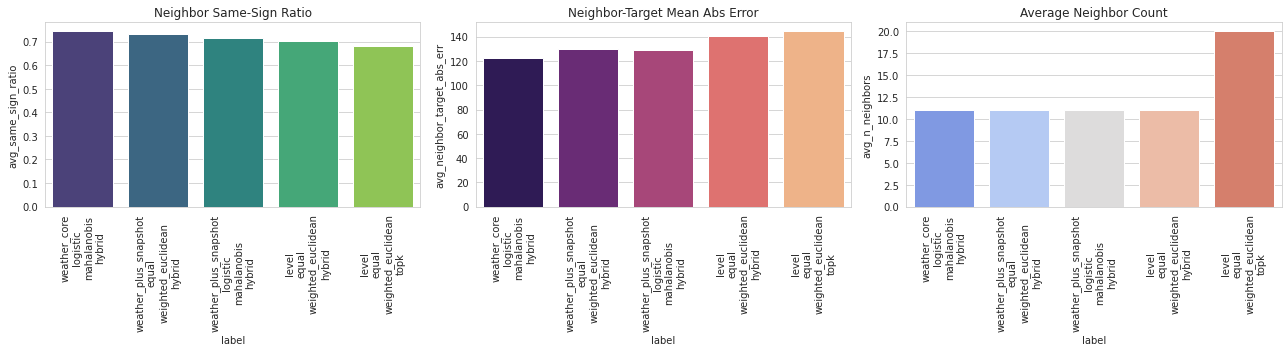

In [35]:
if not diag_compare_df.empty:
    tmp = diag_compare_df.copy()
    tmp['label'] = tmp['feature_set'] + '\n' + tmp['weight_method'] + '\n' + tmp['distance_method'] + '\n' + tmp['select_method']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.barplot(data=tmp, x='label', y='avg_same_sign_ratio', ax=axes[0], palette='viridis')
    axes[0].set_title('Neighbor Same-Sign Ratio')
    axes[0].tick_params(axis='x', rotation=90)
    sns.barplot(data=tmp, x='label', y='avg_neighbor_target_abs_err', ax=axes[1], palette='magma')
    axes[1].set_title('Neighbor-Target Mean Abs Error')
    axes[1].tick_params(axis='x', rotation=90)
    sns.barplot(data=tmp, x='label', y='avg_n_neighbors', ax=axes[2], palette='coolwarm')
    axes[2].set_title('Average Neighbor Count')
    axes[2].tick_params(axis='x', rotation=90)
    plt.tight_layout()
    plt.show()


tp            0.075254
d2            0.073069
t2            0.059621
sf            0.053573
rhu           0.042566
ssrd          0.036014
win100_spd    0.033145
u100          0.030762
sp            0.028566
tcc           0.025353
dtype: float64

ssrd          0.299187
sf            0.172209
tcc           0.112043
tp            0.070673
d2            0.069101
win100_spd    0.060512
sp            0.058324
rhu           0.035511
u100          0.033844
v100          0.032191
dtype: float64

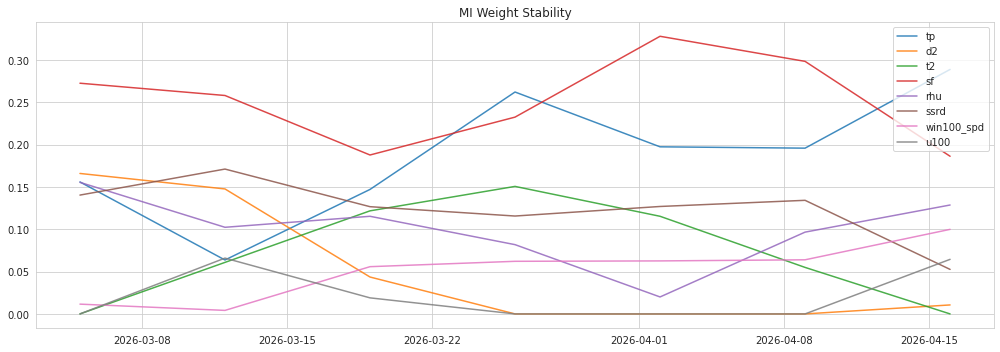

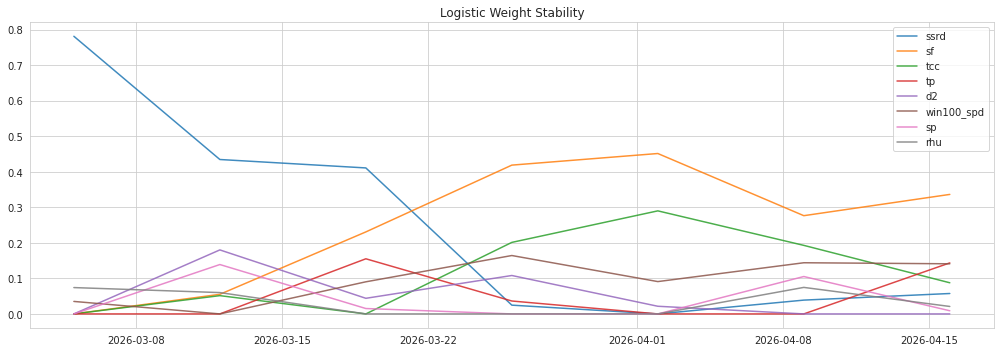

In [36]:
def rolling_weight_stability(df: pd.DataFrame, features: List[str], method: str, label_col: str = 'prc_diff_sign', window_days: int = 40, step_days: int = 7) -> pd.DataFrame:
    features = sanitize_feature_list(df, features)
    d = df.dropna(subset=features + [label_col]).copy().sort_index()
    start_ts = d.index.min() + pd.Timedelta(days=window_days)
    end_ts = d.index.max()
    rows = []
    ts = start_ts
    while ts <= end_ts:
        train = d.loc[(d.index < ts) & (d.index >= ts - pd.Timedelta(days=window_days))].copy()
        if len(train) >= 100:
            w = get_feature_weights(train, features, method)
            row = {'window_end': ts}
            row.update(w.to_dict())
            rows.append(row)
        ts += pd.Timedelta(days=step_days)
    return pd.DataFrame(rows).set_index('window_end') if rows else pd.DataFrame()


def plot_weight_stability(weight_df: pd.DataFrame, title: str, topn: int = 8):
    if weight_df.empty:
        print(title, 'empty')
        return
    vol = weight_df.std().sort_values(ascending=False).head(topn).index.tolist()
    tmp = weight_df[vol].copy()
    plt.figure(figsize=(14, 5))
    for col in tmp.columns:
        plt.plot(tmp.index, tmp[col], label=col, alpha=0.85)
    plt.legend(loc='upper right')
    plt.title(title)
    plt.tight_layout()
    plt.show()


mi_stability = rolling_weight_stability(panel1, feature_groups['level'], method='mi')
logit_stability = rolling_weight_stability(panel1, feature_groups['level'], method='logistic')
display(mi_stability.std().sort_values(ascending=False).head(10))
display(logit_stability.std().sort_values(ascending=False).head(10))
plot_weight_stability(mi_stability, 'MI Weight Stability')
plot_weight_stability(logit_stability, 'Logistic Weight Stability')


# plot

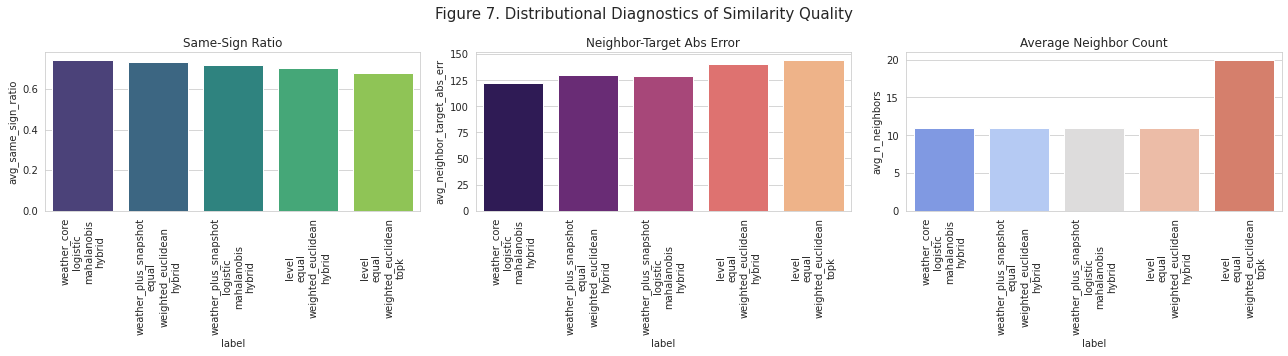

In [45]:
def plot_similarity_quality_bars(diag_compare_df):
    tmp = diag_compare_df.copy()
    tmp["label"] = (
        tmp["feature_set"] + "\n" +
        tmp["weight_method"] + "\n" +
        tmp["distance_method"] + "\n" +
        tmp["select_method"]
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.barplot(data=tmp, x="label", y="avg_same_sign_ratio", ax=axes[0], palette="viridis")
    axes[0].set_title("Same-Sign Ratio")
    axes[0].tick_params(axis="x", rotation=90)

    sns.barplot(data=tmp, x="label", y="avg_neighbor_target_abs_err", ax=axes[1], palette="magma")
    axes[1].set_title("Neighbor-Target Abs Error")
    axes[1].tick_params(axis="x", rotation=90)

    sns.barplot(data=tmp, x="label", y="avg_n_neighbors", ax=axes[2], palette="coolwarm")
    axes[2].set_title("Average Neighbor Count")
    axes[2].tick_params(axis="x", rotation=90)

    fig.suptitle("Figure 7. Distributional Diagnostics of Similarity Quality", fontsize=15)
    plt.tight_layout()
    plt.show()

plot_similarity_quality_bars(diag_compare_df)


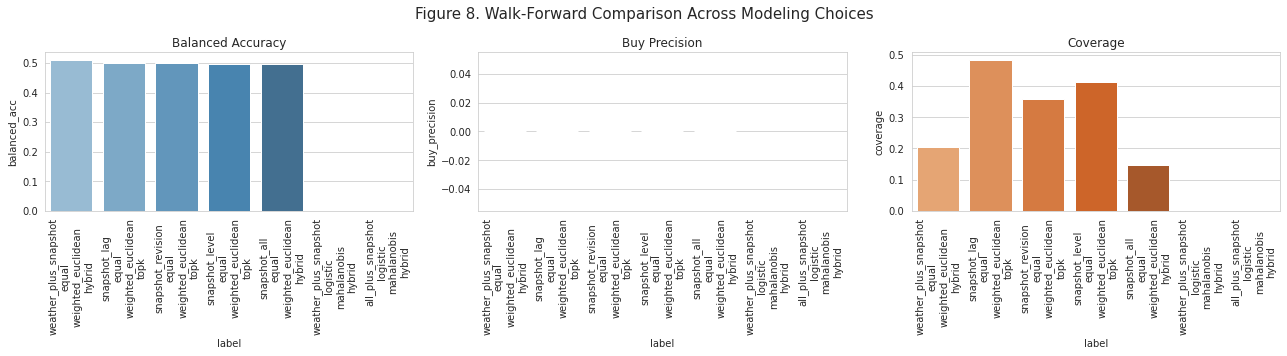

In [46]:
def plot_experiment_summary(snapshot_summary_df):
    tmp = snapshot_summary_df.copy()
    tmp["label"] = (
        tmp["feature_set"] + "\n" +
        tmp["weight_method"] + "\n" +
        tmp["distance_method"] + "\n" +
        tmp["select_method"]
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.barplot(data=tmp, x="label", y="balanced_acc", ax=axes[0], palette="Blues_d")
    axes[0].set_title("Balanced Accuracy")
    axes[0].tick_params(axis="x", rotation=90)

    sns.barplot(data=tmp, x="label", y="buy_precision", ax=axes[1], palette="Greens_d")
    axes[1].set_title("Buy Precision")
    axes[1].tick_params(axis="x", rotation=90)

    sns.barplot(data=tmp, x="label", y="coverage", ax=axes[2], palette="Oranges_d")
    axes[2].set_title("Coverage")
    axes[2].tick_params(axis="x", rotation=90)

    fig.suptitle("Figure 8. Walk-Forward Comparison Across Modeling Choices", fontsize=15)
    plt.tight_layout()
    plt.show()

plot_experiment_summary(snapshot_summary_df)


In [50]:
for key, df in snapshot_results.items():
    if df.empty:
        continue
    print("\n", key)
    print(df["prob_neg"].describe())



 ('snapshot_level', 'equal', 'weighted_euclidean', 'topk')
count    192.000000
mean       0.237456
std        0.097920
min        0.065619
25%        0.167130
50%        0.225747
75%        0.291825
max        0.515930
Name: prob_neg, dtype: float64

 ('snapshot_revision', 'equal', 'weighted_euclidean', 'topk')
count    192.000000
mean       0.244516
std        0.097217
min        0.067572
25%        0.179891
50%        0.244775
75%        0.308127
max        0.486630
Name: prob_neg, dtype: float64

 ('snapshot_lag', 'equal', 'weighted_euclidean', 'topk')
count    192.000000
mean       0.233910
std        0.100014
min        0.066110
25%        0.157584
50%        0.218567
75%        0.289038
max        0.489431
Name: prob_neg, dtype: float64

 ('snapshot_all', 'equal', 'weighted_euclidean', 'hybrid')
count    192.000000
mean       0.240094
std        0.079256
min        0.116037
25%        0.183008
50%        0.238259
75%        0.290332
max        0.524141
Name: prob_neg, dtype: flo

In [51]:
for key, df in snapshot_results.items():
    if df.empty:
        continue
    print(key, "negative spread base rate =", (df["real_spread"] < 0).mean())


('snapshot_level', 'equal', 'weighted_euclidean', 'topk') negative spread base rate = 0.23958333333333334
('snapshot_revision', 'equal', 'weighted_euclidean', 'topk') negative spread base rate = 0.23958333333333334
('snapshot_lag', 'equal', 'weighted_euclidean', 'topk') negative spread base rate = 0.23958333333333334
('snapshot_all', 'equal', 'weighted_euclidean', 'hybrid') negative spread base rate = 0.23958333333333334
('weather_plus_snapshot', 'equal', 'weighted_euclidean', 'hybrid') negative spread base rate = 0.23958333333333334
('weather_plus_snapshot', 'logistic', 'mahalanobis', 'hybrid') negative spread base rate = 0.23958333333333334
('all_plus_snapshot', 'logistic', 'mahalanobis', 'hybrid') negative spread base rate = 0.23958333333333334


In [52]:
for key, df in snapshot_results.items():
    if df.empty:
        continue
    buy_df = df[df["signal"] == 1]
    if len(buy_df) == 0:
        print(key, "no buy")
    else:
        print(key, "buy precision =", (buy_df["real_spread"] < 0).mean())


('snapshot_level', 'equal', 'weighted_euclidean', 'topk') no buy
('snapshot_revision', 'equal', 'weighted_euclidean', 'topk') no buy
('snapshot_lag', 'equal', 'weighted_euclidean', 'topk') no buy
('snapshot_all', 'equal', 'weighted_euclidean', 'hybrid') no buy
('weather_plus_snapshot', 'equal', 'weighted_euclidean', 'hybrid') no buy
('weather_plus_snapshot', 'logistic', 'mahalanobis', 'hybrid') no buy
('all_plus_snapshot', 'logistic', 'mahalanobis', 'hybrid') no buy


In [53]:
panel_snap.groupby(panel_snap.index.hour)["prc_diff"].apply(lambda x: (x < 0).mean())


0     0.214286
1     0.214286
2     0.285714
3     0.196429
4     0.142857
5     0.160714
6     0.142857
7     0.142857
8     0.053571
9     0.375000
10    0.250000
11    0.285714
12    0.160714
13    0.142857
14    0.142857
15    0.232143
16    0.375000
17    0.089286
18    0.125000
19    0.392857
20    0.428571
21    0.375000
22    0.482143
23    0.482143
Name: prc_diff, dtype: float64

# update

In [25]:
panel_snap

,mid_price,best_bid_price,best_ask_price,spread_book,rt,prc_diff,prc_diff_sign,hour,month,dayofweek,d2,rhu,sf,sp,ssrd,t2,tcc,tp,u100,v100,win100_spd,win100_spd_diff_lag1,win100_spd_diff_lag4,win100_spd_rollmean_3,win100_spd_rollstd_3,win100_spd_slope_3,win100_spd_rollmean_6,win100_spd_rollstd_6,win100_spd_slope_6,t2_diff_lag1,t2_diff_lag4,t2_rollmean_3,t2_rollstd_3,t2_slope_3,t2_rollmean_6,t2_rollstd_6,t2_slope_6,rhu_diff_lag1,rhu_diff_lag4,rhu_rollmean_3,rhu_rollstd_3,rhu_slope_3,rhu_rollmean_6,rhu_rollstd_6,rhu_slope_6,d2_diff_lag1,d2_diff_lag4,d2_rollmean_3,d2_rollstd_3,d2_slope_3,d2_rollmean_6,d2_rollstd_6,d2_slope_6,sf_diff_lag1,sf_diff_lag4,sf_rollmean_3,sf_rollstd_3,sf_slope_3,sf_rollmean_6,sf_rollstd_6,sf_slope_6,sp_diff_lag1,sp_diff_lag4,sp_rollmean_3,sp_rollstd_3,sp_slope_3,sp_rollmean_6,sp_rollstd_6,sp_slope_6,tp_diff_lag1,tp_diff_lag4,tp_rollmean_3,tp_rollstd_3,tp_slope_3,tp_rollmean_6,tp_rollstd_6,tp_slope_6,ssrd_diff_lag1,ssrd_diff_lag4,ssrd_rollmean_3,ssrd_rollstd_3,ssrd_slope_3,ssrd_rollmean_6,ssrd_rollstd_6,ssrd_slope_6,u100_diff_lag1,u100_diff_lag4,u100_rollmean_3,u100_rollstd_3,u100_slope_3,u100_rollmean_6,u100_rollstd_6,u100_slope_6,v100_diff_lag1,v100_diff_lag4,v100_rollmean_3,v100_rollstd_3,v100_slope_3,v100_rollmean_6,v100_rollstd_6,v100_slope_6,tcc_diff_lag1,tcc_diff_lag4,tcc_rollmean_3,tcc_rollstd_3,tcc_slope_3,tcc_rollmean_6,tcc_rollstd_6,tcc_slope_6,prc_diff_lag1,prc_diff_lag2,prc_diff_rollmean_3,prc_diff_rollstd_3,mid_price_diff1,spread_book_rollmean_3,spread_book_rollstd_3,is_weekend,is_night,is_peak_hour,d2_w2,rhu_w2,sf_w2,sp_w2,ssrd_w2,t2_w2,tcc_w2,tp_w2,u100_w2,v100_w2,win100_spd_w2,d2_w3,rhu_w3,sf_w3,sp_w3,ssrd_w3,t2_w3,tcc_w3,tp_w3,u100_w3,v100_w3,win100_spd_w3,d2_w4,rhu_w4,sf_w4,sp_w4,ssrd_w4,t2_w4,tcc_w4,tp_w4,u100_w4,v100_w4,win100_spd_w4,d2_trend_3,rhu_trend_3,sf_trend_3,sp_trend_3,ssrd_trend_3,t2_trend_3,tcc_trend_3,tp_trend_3,u100_trend_3,v100_trend_3,win100_spd_trend_3,d2_trend_4,rhu_trend_4,sf_trend_4,sp_trend_4,ssrd_trend_4,t2_trend_4,tcc_trend_4,tp_trend_4,u100_trend_4,v100_trend_4,win100_spd_trend_4,d2_rev_43,rhu_rev_43,sf_rev_43,sp_rev_43,ssrd_rev_43,t2_rev_43,tcc_rev_43,tp_rev_43,u100_rev_43,v100_rev_43,win100_spd_rev_43,d2_w2_lag1,rhu_w2_lag1,sf_w2_lag1,sp_w2_lag1,ssrd_w2_lag1,t2_w2_lag1,tcc_w2_lag1,tp_w2_lag1,u100_w2_lag1,v100_w2_lag1,win100_spd_w2_lag1,d2_w2_lag3,rhu_w2_lag3,sf_w2_lag3,sp_w2_lag3,ssrd_w2_lag3,t2_w2_lag3,tcc_w2_lag3,tp_w2_lag3,u100_w2_lag3,v100_w2_lag3,win100_spd_w2_lag3,win100_spd_rev_abs_sum,win100_spd_rev_sign_agree,win100_spd_rev_accel,t2_rev_abs_sum,t2_rev_sign_agree,t2_rev_accel,rhu_rev_abs_sum,rhu_rev_sign_agree,rhu_rev_accel,d2_rev_abs_sum,d2_rev_sign_agree,d2_rev_accel,sf_rev_abs_sum,sf_rev_sign_agree,sf_rev_accel,sp_rev_abs_sum,sp_rev_sign_agree,sp_rev_accel,tp_rev_abs_sum,tp_rev_sign_agree,tp_rev_accel,ssrd_rev_abs_sum,ssrd_rev_sign_agree,ssrd_rev_accel,u100_rev_abs_sum,u100_rev_sign_agree,u100_rev_accel,v100_rev_abs_sum,v100_rev_sign_agree,v100_rev_accel,tcc_rev_abs_sum,tcc_rev_sign_agree,tcc_rev_accel
2026-01-24 00:00:00,258.0495,251.100,264.999,13.899,0.0,258.0495,1.0,0,1,5,-10.083333,62.572222,0.006944,890.123611,0.000000,-3.683333,0.541667,0.013889,-0.905556,2.455556,3.415278,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,-10.821918,59.780822,0.005479,889.056164,0.000000,-3.795890,10.684932,0.006849,-1.187671,2.471233,3.712329,-10.821918,59.780822,0.005479,889.056164,0.000000,-3.795890,10.684932,0.006849,-1.187671,2.471233e+00,3.712329,-11.308219,58.486301,0.172603,889.938356,0.000000,-3.838356,0.013699,0.179452,-1.695890,1.789041,3.532877,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0

0     0.200000
1     0.200000
2     0.283333
3     0.200000
4     0.150000
5     0.150000
6     0.133333
7     0.133333
8     0.050000
9     0.350000
10    0.233333
11    0.266667
12    0.150000
13    0.133333
14    0.133333
15    0.216667
16    0.366667
17    0.083333
18    0.116667
19    0.383333
20    0.416667
21    0.366667
22    0.500000
23    0.483333
Name: prc_diff, dtype: float64

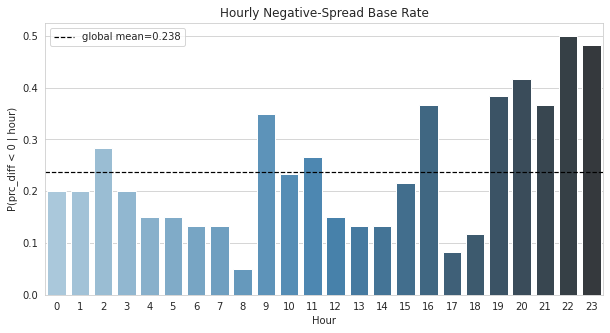

In [59]:
def compute_hourly_base_rate(df: pd.DataFrame) -> pd.Series:
    return df.groupby(df.index.hour)['prc_diff'].apply(lambda x: (x < 0).mean())


hourly_base_rate = compute_hourly_base_rate(panel_snap)
display(hourly_base_rate)

plt.figure(figsize=(10, 5))
sns.barplot(x=hourly_base_rate.index, y=hourly_base_rate.values, palette='Blues_d')
plt.axhline(hourly_base_rate.mean(), color='black', ls='--', lw=1.2, label=f'global mean={hourly_base_rate.mean():.3f}')
plt.title('Hourly Negative-Spread Base Rate')
plt.xlabel('Hour')
plt.ylabel('P(prc_diff < 0 | hour)')
plt.legend()
plt.show()


In [75]:
HIGH_NEG_HOURS = hourly_base_rate[hourly_base_rate >= 0.30].index.tolist()
MID_NEG_HOURS = hourly_base_rate[(hourly_base_rate >= 0.20) & (hourly_base_rate < 0.30)].index.tolist()
LOW_NEG_HOURS = hourly_base_rate[hourly_base_rate < 0.20].index.tolist()

print('HIGH_NEG_HOURS =', HIGH_NEG_HOURS)
print('MID_NEG_HOURS =', MID_NEG_HOURS)
print('LOW_NEG_HOURS =', LOW_NEG_HOURS)


HIGH_NEG_HOURS = [9, 16, 19, 20, 21, 22, 23]
MID_NEG_HOURS = [0, 1, 2, 3, 10, 11, 15]
LOW_NEG_HOURS = [4, 5, 6, 7, 8, 12, 13, 14, 17, 18]


In [76]:
def compute_hourly_priors(train_df: pd.DataFrame) -> pd.DataFrame:
    global_neg_prior = float((train_df['prc_diff'] < 0).mean())
    global_pos_prior = float((train_df['prc_diff'] > 0).mean())

    out = train_df.groupby(train_df.index.hour).apply(
        lambda x: pd.Series({
            'neg_prior': float((x['prc_diff'] < 0).mean()),
            'pos_prior': float((x['prc_diff'] > 0).mean()),
            'count': int(len(x)),
        })
    )

    out = out.reindex(range(24))
    out['count'] = out['count'].fillna(0).astype(int)
    out['neg_prior'] = out['neg_prior'].fillna(global_neg_prior)
    out['pos_prior'] = out['pos_prior'].fillna(global_pos_prior)
    return out


def get_hourly_prior(train_df: pd.DataFrame, target_ts) -> dict:
    hourly_priors = compute_hourly_priors(train_df)
    hour = pd.Timestamp(target_ts).hour
    row = hourly_priors.loc[hour]
    return {
        'hour': hour,
        'hourly_neg_prior': float(row['neg_prior']),
        'hourly_pos_prior': float(row['pos_prior']),
        'hourly_prior_sample_count': int(row['count']),
    }


display(compute_hourly_priors(panel_snap))


,neg_prior,pos_prior,count
0,0.200000,0.800000,60.0
1,0.200000,0.800000,60.0
2,0.283333,0.716667,60.0
3,0.200000,0.800000,60.0
4,0.150000,0.850000,60.0
5,0.150000,0.850000,60.0
6,0.133333,0.866667,60.0
7,0.133333,0.866667,60.0
8,0.050000,0.950000,60.0
9,0.350000,0.650000,60.0


In [67]:
def compute_shrinkage_mix(n_eff: float, prior_strength: float) -> dict:
    denom = max(n_eff + prior_strength, 1e-12)
    neighbor_weight_share = float(n_eff / denom)
    prior_weight_share = float(prior_strength / denom)
    return {
        'neighbor_weight_share': neighbor_weight_share,
        'prior_weight_share': prior_weight_share,
    }


def apply_prior_shrinkage(raw_prob: float, prior_prob: float, n_eff: float, prior_strength: float) -> tuple[float, dict]:
    mix = compute_shrinkage_mix(n_eff=n_eff, prior_strength=prior_strength)
    posterior = float(
        mix['neighbor_weight_share'] * raw_prob +
        mix['prior_weight_share'] * prior_prob
    )
    return posterior, mix


def score_neighbors_hourly(
    neigh: pd.DataFrame,
    dist_s: pd.Series,
    target_ts,
    full_train_df: pd.DataFrame,
    prior_strength: float = 3.0,
    time_decay_half_life_days: float = 14.0,
) -> dict:
    if len(neigh) == 0:
        return {
            'n_sample': 0,
            'n_eff': 0.0,
            'raw_prob_neg': 0.0,
            'raw_prob_pos': 0.0,
            'prob_neg': 0.0,
            'prob_pos': 0.0,
            'exp_spread': 0.0,
            'spread_std': np.nan,
            'confidence': 0.0,
            'hour': pd.Timestamp(target_ts).hour,
            'hourly_neg_prior': np.nan,
            'hourly_pos_prior': np.nan,
            'hourly_prior_sample_count': 0,
            'neighbor_weight_share': np.nan,
            'prior_weight_share': np.nan,
            'prior_strength': float(prior_strength),
            'time_decay_half_life_days': float(time_decay_half_life_days),
            'prob_neg_excess': np.nan,
            'prob_neg_lift': np.nan,
        }

    w = build_neighbor_weights(
        neigh.index,
        dist_s,
        target_ts,
        time_decay_half_life_days=time_decay_half_life_days,
    )
    n_eff = effective_sample_size(w)

    prior_info = get_hourly_prior(full_train_df, target_ts)
    hourly_neg_prior = prior_info['hourly_neg_prior']
    hourly_pos_prior = prior_info['hourly_pos_prior']

    raw_prob_neg = float(np.sum((neigh['prc_diff'] < 0).astype(float).values * w.values))
    raw_prob_pos = float(np.sum((neigh['prc_diff'] > 0).astype(float).values * w.values))

    prob_neg, mix = apply_prior_shrinkage(
        raw_prob=raw_prob_neg,
        prior_prob=hourly_neg_prior,
        n_eff=n_eff,
        prior_strength=prior_strength,
    )
    prob_pos, _ = apply_prior_shrinkage(
        raw_prob=raw_prob_pos,
        prior_prob=hourly_pos_prior,
        n_eff=n_eff,
        prior_strength=prior_strength,
    )

    exp_spread = float(np.sum(neigh['prc_diff'].values * w.values))
    spread_std = float(np.sqrt(np.sum(w.values * np.square(neigh['prc_diff'].values - exp_spread)))) if len(neigh) > 1 else 0.0

    avg_dist = float(dist_s.loc[neigh.index].mean())
    confidence = float(
        mix['neighbor_weight_share'] *
        (1.0 / (1.0 + avg_dist)) *
        (1.0 / (1.0 + spread_std / 100.0))
    )

    prob_neg_excess = prob_neg - hourly_neg_prior
    prob_neg_lift = prob_neg / max(hourly_neg_prior, 1e-6)

    return {
        'n_sample': len(neigh),
        'n_eff': n_eff,
        'raw_prob_neg': raw_prob_neg,
        'raw_prob_pos': raw_prob_pos,
        'prob_neg': prob_neg,
        'prob_pos': prob_pos,
        'exp_spread': exp_spread,
        'spread_std': spread_std,
        'confidence': confidence,
        'hour': prior_info['hour'],
        'hourly_neg_prior': hourly_neg_prior,
        'hourly_pos_prior': hourly_pos_prior,
        'hourly_prior_sample_count': prior_info['hourly_prior_sample_count'],
        'neighbor_weight_share': mix['neighbor_weight_share'],
        'prior_weight_share': mix['prior_weight_share'],
        'prior_strength': float(prior_strength),
        'time_decay_half_life_days': float(time_decay_half_life_days),
        'prob_neg_excess': prob_neg_excess,
        'prob_neg_lift': prob_neg_lift,
    }


In [62]:
def map_signal_hourly(
    prob_neg: float,
    prob_pos: float,
    confidence: float,
    exp_spread: float,
    hourly_neg_prior: float,
    prob_neg_excess: float,
    prob_neg_lift: float,
    buy_excess_th: float = 0.04,
    buy_lift_th: float = 1.2,
    conf_th: float = 0.1,
    sell_prob_th: float = 0.72,
) -> float:
    if confidence < conf_th:
        return 0.0

    if (prob_neg_excess >= buy_excess_th) and (prob_neg_lift >= buy_lift_th) and (exp_spread < 0):
        return 1.0

    if (prob_pos >= sell_prob_th) and (exp_spread > 0):
        return -1.0

    return 0.0


In [63]:
def predict_one_timestamp_hourly(
    full_train_df: pd.DataFrame,
    target_row: pd.Series,
    features: list,
    cfg,
):
    candidates = filter_candidates(
        full_train_df,
        target_row.name,
        hour_only=True,
        same_month=cfg.same_month,
        same_weekend_flag=cfg.same_weekend_flag,
    )

    features = sanitize_feature_list(candidates, features)
    if len(features) == 0:
        return {
            'ts': target_row.name,
            'signal': 0.0,
            'n_sample': 0,
            'n_eff': 0.0,
            'prob_neg': 0.0,
            'prob_pos': 0.0,
            'raw_prob_neg': 0.0,
            'raw_prob_pos': 0.0,
            'hour': pd.Timestamp(target_row.name).hour,
            'hourly_neg_prior': np.nan,
            'hourly_pos_prior': np.nan,
            'hourly_prior_sample_count': 0,
            'neighbor_weight_share': np.nan,
            'prior_weight_share': np.nan,
            'prior_strength': float(cfg.prior_strength),
            'time_decay_half_life_days': float(cfg.time_decay_half_life_days),
            'prob_neg_excess': np.nan,
            'prob_neg_lift': np.nan,
            'exp_spread': 0.0,
            'spread_std': np.nan,
            'confidence': 0.0,
            'neighbor_dates': [],
        }

    needed_cols = features + ['prc_diff', 'prc_diff_sign']
    candidates = candidates.dropna(subset=needed_cols).copy()
    if len(candidates) < max(cfg.min_samples, 20):
        return {
            'ts': target_row.name,
            'signal': 0.0,
            'n_sample': 0,
            'n_eff': 0.0,
            'prob_neg': 0.0,
            'prob_pos': 0.0,
            'raw_prob_neg': 0.0,
            'raw_prob_pos': 0.0,
            'hour': pd.Timestamp(target_row.name).hour,
            'hourly_neg_prior': np.nan,
            'hourly_pos_prior': np.nan,
            'hourly_prior_sample_count': 0,
            'neighbor_weight_share': np.nan,
            'prior_weight_share': np.nan,
            'prior_strength': float(cfg.prior_strength),
            'time_decay_half_life_days': float(cfg.time_decay_half_life_days),
            'prob_neg_excess': np.nan,
            'prob_neg_lift': np.nan,
            'exp_spread': 0.0,
            'spread_std': np.nan,
            'confidence': 0.0,
            'neighbor_dates': [],
        }

    weights = get_feature_weights(candidates, features, cfg.weight_method)

    cand_z = candidates.copy()
    tgt_z = target_row.copy()

    cand_z_values = zscore_by_train(candidates, candidates, features)
    tgt_z_values = zscore_by_train(candidates, pd.DataFrame([target_row]), features)

    cand_z.loc[:, features] = cand_z_values.to_numpy()
    tgt_z.loc[features] = tgt_z_values.iloc[0].reindex(features).to_numpy()

    neigh, dist_s = select_neighbors(
        cand_z,
        tgt_z,
        features,
        weights,
        distance_method=cfg.distance_method,
        select_method=cfg.select_method,
        topk=cfg.topk,
        radius_q=cfg.radius_q,
        min_samples=cfg.min_samples,
        max_samples=cfg.max_samples,
    )

    stats = score_neighbors_hourly(
        neigh=neigh,
        dist_s=dist_s,
        target_ts=target_row.name,
        full_train_df=full_train_df,
        prior_strength=cfg.prior_strength,
        time_decay_half_life_days=cfg.time_decay_half_life_days,
    )

    signal = map_signal_hourly(
        prob_neg=stats['prob_neg'],
        prob_pos=stats['prob_pos'],
        confidence=stats['confidence'],
        exp_spread=stats['exp_spread'],
        hourly_neg_prior=stats['hourly_neg_prior'],
        prob_neg_excess=stats['prob_neg_excess'],
        prob_neg_lift=stats['prob_neg_lift'],
    )

    return {
        'ts': target_row.name,
        **stats,
        'signal': signal,
        'neighbor_dates': [str(x) for x in neigh.index[:10]],
    }


def run_walkforward_experiment_hourly(
    full_df: pd.DataFrame,
    feature_list: list,
    cfg,
    train_lookback_days: int = 40,
    test_start: str = '2026-03-01',
    test_end: str = '2026-03-29',
):
    feature_list = sanitize_feature_list(full_df, feature_list)
    d = full_df.dropna(subset=feature_list + ['prc_diff', 'prc_diff_sign']).copy().sort_index()
    test_index = d.loc[test_start:test_end].index

    rows = []
    for ts in test_index:
        train_start = ts - pd.Timedelta(days=train_lookback_days)
        train_df = d.loc[(d.index < ts) & (d.index >= train_start)].copy()
        if len(train_df) < 100:
            continue

        target_row = d.loc[ts]
        res = predict_one_timestamp_hourly(train_df, target_row, feature_list, cfg)
        res['real_spread'] = float(target_row['prc_diff'])
        res['real_sign'] = float(np.sign(target_row['prc_diff']))
        rows.append(res)

    return pd.DataFrame(rows).set_index('ts').sort_index() if rows else pd.DataFrame()


In [64]:
def evaluate_prediction_result_hourly(pred_df: pd.DataFrame) -> pd.Series:
    if pred_df.empty:
        return pd.Series(dtype=float)

    buy_df = pred_df[pred_df['signal'] == 1].copy()
    sell_df = pred_df[pred_df['signal'] == -1].copy()

    out = {
        'n_total': len(pred_df),
        'buy_count': len(buy_df),
        'sell_count': len(sell_df),
        'buy_coverage': len(buy_df) / len(pred_df),
        'sell_coverage': len(sell_df) / len(pred_df),
        'avg_prob_neg': pred_df['prob_neg'].mean(),
        'avg_hourly_neg_prior': pred_df['hourly_neg_prior'].mean(),
        'avg_prob_neg_excess': pred_df['prob_neg_excess'].mean(),
        'avg_prob_neg_lift': pred_df['prob_neg_lift'].mean(),
    }

    if len(buy_df) > 0:
        out['buy_hit_rate'] = float((buy_df['real_spread'] < 0).mean())
        out['buy_avg_real_spread'] = float(buy_df['real_spread'].mean())
        out['buy_avg_prob_neg_excess'] = float(buy_df['prob_neg_excess'].mean())
        out['buy_avg_prob_neg_lift'] = float(buy_df['prob_neg_lift'].mean())
        out['buy_avg_confidence'] = float(buy_df['confidence'].mean())
    else:
        out['buy_hit_rate'] = np.nan
        out['buy_avg_real_spread'] = np.nan
        out['buy_avg_prob_neg_excess'] = np.nan
        out['buy_avg_prob_neg_lift'] = np.nan
        out['buy_avg_confidence'] = np.nan

    return pd.Series(out)


def evaluate_on_selected_hours(pred_df: pd.DataFrame, hours: list) -> pd.Series:
    d = pred_df[pred_df.index.hour.isin(hours)].copy()
    return evaluate_prediction_result_hourly(d)


In [68]:
# Keep only the hourly-prior strategy version.
HOURLY_PRIOR_CFG = ExperimentConfig(
    'weather_plus_snapshot',
    'equal',
    'weighted_euclidean',
    'hybrid',
    topk=20,
    radius_q=0.2,
    min_samples=5,
    max_samples=40,
    prior_strength=8.0,
    time_decay_half_life_days=14.0,
)

hourly_feature_list = feature_groups_v3[HOURLY_PRIOR_CFG.feature_set_name]
hourly_pred_df = run_walkforward_experiment_hourly(
    full_df=panel_snap,
    feature_list=hourly_feature_list,
    cfg=HOURLY_PRIOR_CFG,
    train_lookback_days=40,
    test_start='2026-04-15',
    test_end='2026-04-25',
)

hourly_summary_df = evaluate_prediction_result_hourly(hourly_pred_df).to_frame('hourly_prior_strategy')
hourly_summary_high_df = evaluate_on_selected_hours(hourly_pred_df, HIGH_NEG_HOURS).to_frame('hourly_prior_strategy_high_neg_hours')

print('Only hourly prior strategy is kept in this section.')
print('prior_strength controls prior_weight_share = prior_strength / (n_eff + prior_strength).')
print('time_decay_half_life_days is used inside build_neighbor_weights for exponential recency decay.')
display(hourly_summary_df)
display(hourly_summary_high_df)


,n_total,buy_count,sell_count,buy_coverage,sell_coverage,avg_prob_neg,avg_hourly_neg_prior,avg_prob_neg_excess,avg_prob_neg_lift,buy_hit_rate,buy_avg_real_spread,buy_avg_prob_neg_excess,buy_avg_prob_neg_lift,buy_avg_confidence,feature_set,weight_method,distance_method,select_method
0,216.0,2.0,57.0,0.009259,0.263889,0.221332,0.213863,0.007469,1.005457,0.0,239.744999,0.145579,1.875018,0.109547,snapshot_all,equal,weighted_euclidean,hybrid
1,216.0,1.0,74.0,0.004630,0.342593,0.205271,0.213863,-0.008593,0.905120,0.0,242.210499,0.121199,1.818096,0.115409,weather_plus_snapshot,equal,weighted_euclidean,hybrid
2,216.0,0.0,0.0,0.000000,0.000000,0.211476,0.213863,-0.002387,0.956193,NaN,NaN,NaN,NaN,NaN,weather_plus_snapshot,logistic,mahalanobis,hybrid
3,216.0,0.0,0.0,0.000000,0.000000,0.210869,0.213863,-0.002994,0.948377,NaN,NaN,NaN,NaN,NaN,all_plus_snapshot,logistic,mahalanobis,hybrid


,n_total,buy_count,sell_count,buy_coverage,sell_coverage,avg_prob_neg,avg_hourly_neg_prior,avg_prob_neg_excess,avg_prob_neg_lift,buy_hit_rate,buy_avg_real_spread,buy_avg_prob_neg_excess,buy_avg_prob_neg_lift,buy_avg_confidence,feature_set,weight_method,distance_method,select_method
0,63.0,0.0,2.0,0.0,0.031746,0.382518,0.378286,0.004232,1.012547,NaN,NaN,NaN,NaN,NaN,snapshot_all,equal,weighted_euclidean,hybrid
3,63.0,0.0,0.0,0.0,0.000000,0.382482,0.378286,0.004196,1.007156,NaN,NaN,NaN,NaN,NaN,all_plus_snapshot,logistic,mahalanobis,hybrid
1,63.0,0.0,6.0,0.0,0.095238,0.380038,0.378286,0.001753,1.001815,NaN,NaN,NaN,NaN,NaN,weather_plus_snapshot,equal,weighted_euclidean,hybrid
2,63.0,0.0,0.0,0.0,0.000000,0.378796,0.378286,0.000510,0.999683,NaN,NaN,NaN,NaN,NaN,weather_plus_snapshot,logistic,mahalanobis,hybrid


Using example key: ('snapshot_all', 'equal', 'weighted_euclidean', 'hybrid')


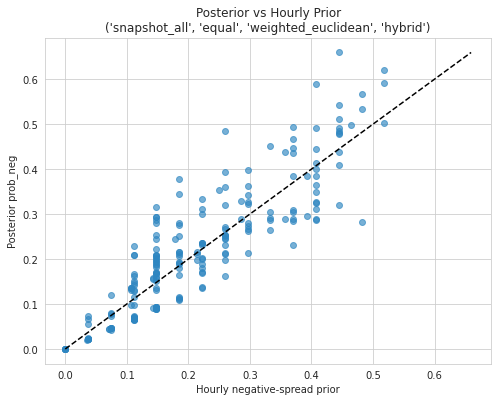

In [69]:
def plot_prob_vs_hourly_prior(pred_df: pd.DataFrame, title='Posterior vs Hourly Prior'):
    tmp = pred_df.dropna(subset=['hourly_neg_prior', 'prob_neg']).copy()
    if tmp.empty:
        print('empty')
        return

    plt.figure(figsize=(8, 6))
    plt.scatter(tmp['hourly_neg_prior'], tmp['prob_neg'], alpha=0.65, color='#2E86C1')
    lims = [
        min(tmp['hourly_neg_prior'].min(), tmp['prob_neg'].min()),
        max(tmp['hourly_neg_prior'].max(), tmp['prob_neg'].max()),
    ]
    plt.plot(lims, lims, '--', color='black')
    plt.xlabel('Hourly negative-spread prior')
    plt.ylabel('Posterior prob_neg')
    plt.title(title)
    plt.show()


plot_prob_vs_hourly_prior(hourly_pred_df, title='Posterior vs Hourly Prior')


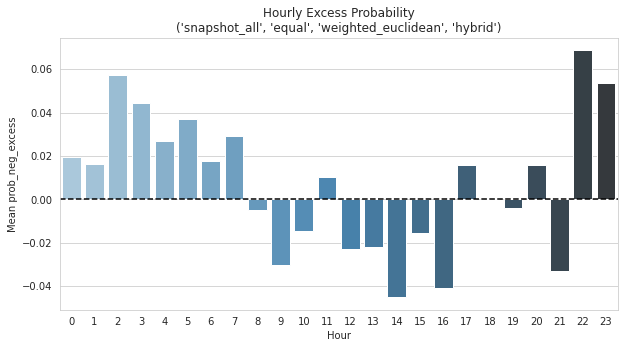

In [70]:
def plot_hourly_excess(pred_df: pd.DataFrame, title='Hourly Excess Probability'):
    tmp = pred_df.dropna(subset=['prob_neg_excess']).copy()
    if tmp.empty:
        print('empty')
        return

    hourly = tmp.groupby(tmp.index.hour)['prob_neg_excess'].mean()
    plt.figure(figsize=(10, 5))
    sns.barplot(x=hourly.index, y=hourly.values, palette='Blues_d')
    plt.axhline(0, color='black', linestyle='--')
    plt.xlabel('Hour')
    plt.ylabel('Mean prob_neg_excess')
    plt.title(title)
    plt.show()


plot_hourly_excess(hourly_pred_df, title='Hourly Excess Probability')


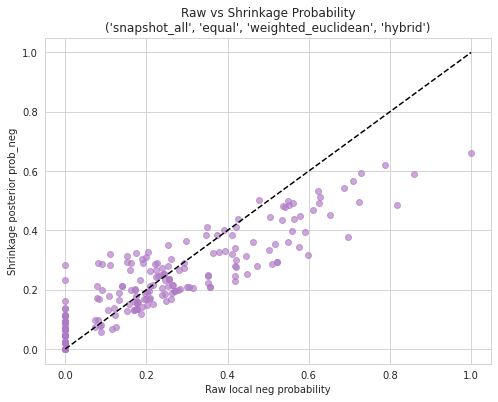

In [71]:
def plot_raw_vs_shrinkage(pred_df: pd.DataFrame, title='Raw vs Shrinkage Probability'):
    tmp = pred_df.dropna(subset=['raw_prob_neg', 'prob_neg']).copy()
    if tmp.empty:
        print('empty')
        return

    plt.figure(figsize=(8, 6))
    plt.scatter(tmp['raw_prob_neg'], tmp['prob_neg'], alpha=0.65, color='#AF7AC5')
    lims = [
        min(tmp['raw_prob_neg'].min(), tmp['prob_neg'].min()),
        max(tmp['raw_prob_neg'].max(), tmp['prob_neg'].max()),
    ]
    plt.plot(lims, lims, '--', color='black')
    plt.xlabel('Raw local neg probability')
    plt.ylabel('Shrinkage posterior prob_neg')
    plt.title(title)
    plt.show()


plot_raw_vs_shrinkage(hourly_pred_df, title='Raw vs Shrinkage Probability')


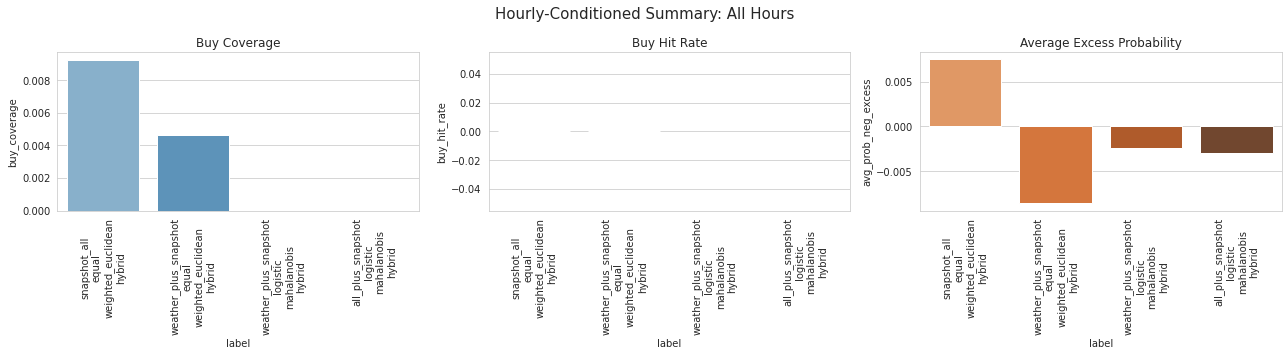

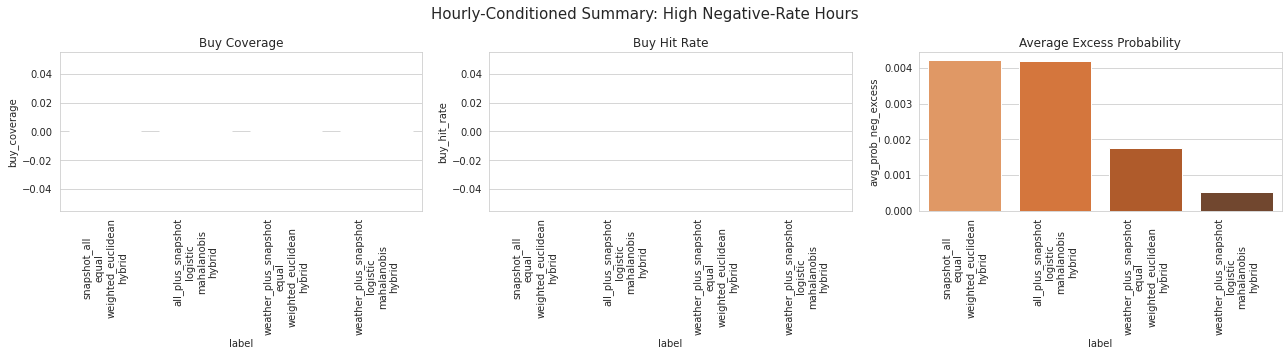

In [72]:
def plot_hourly_strategy_diagnostics(pred_df: pd.DataFrame, title='Hourly Prior Strategy Diagnostics'):
    tmp = pred_df.dropna(subset=['prior_weight_share', 'neighbor_weight_share']).copy()
    if tmp.empty:
        print('empty')
        return

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(tmp['prior_weight_share'], bins=20, color='#2E86C1', ax=axes[0])
    axes[0].set_title('Prior Weight Share')
    axes[0].set_xlabel('prior_strength / (n_eff + prior_strength)')

    sns.histplot(tmp['neighbor_weight_share'], bins=20, color='#28B463', ax=axes[1])
    axes[1].set_title('Neighbor Weight Share')
    axes[1].set_xlabel('n_eff / (n_eff + prior_strength)')

    sns.scatterplot(data=tmp, x='n_eff', y='prior_weight_share', hue='hour', palette='viridis', ax=axes[2], legend=False)
    axes[2].set_title('Shrinkage vs Effective Sample Size')
    axes[2].set_xlabel('n_eff')
    axes[2].set_ylabel('prior_weight_share')

    fig.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.show()


plot_hourly_strategy_diagnostics(hourly_pred_df)


# only neg hour， grid search param

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

BASELINE_CFG = ExperimentConfig(
    'weather_plus_snapshot',
    'equal',
    'weighted_euclidean',
    'hybrid',
    topk=20,
    radius_q=0.2,
    min_samples=5,
    max_samples=40,
    prior_strength=8.0,
    time_decay_half_life_days=14.0,
)

BASELINE_FEATURES = feature_groups_v3[BASELINE_CFG.feature_set_name]
print('HIGH_NEG_HOURS =', HIGH_NEG_HOURS)
print('feature count =', len(BASELINE_FEATURES))

hourly_prior_example = hourly_pred_df[[
    'hour',
    'n_sample',
    'n_eff',
    'raw_prob_neg',
    'hourly_neg_prior',
    'prob_neg',
    'prob_neg_excess',
    'neighbor_weight_share',
    'prior_weight_share',
    'prior_strength',
    'time_decay_half_life_days',
    'confidence',
    'exp_spread',
    'real_spread',
    'neighbor_dates',
]].copy()

display(hourly_prior_example.head(20))

print('Scaling comes from Bayesian shrinkage with effective sample size:')
print('neighbor_weight_share = n_eff / (n_eff + prior_strength)')
print('prior_weight_share    = prior_strength / (n_eff + prior_strength)')
print('time_decay_half_life_days is already used when building neighbor weights,')
print('so older neighbors contribute exponentially less to raw_prob_neg and exp_spread.')
